▶  EDA 1: Target distribution


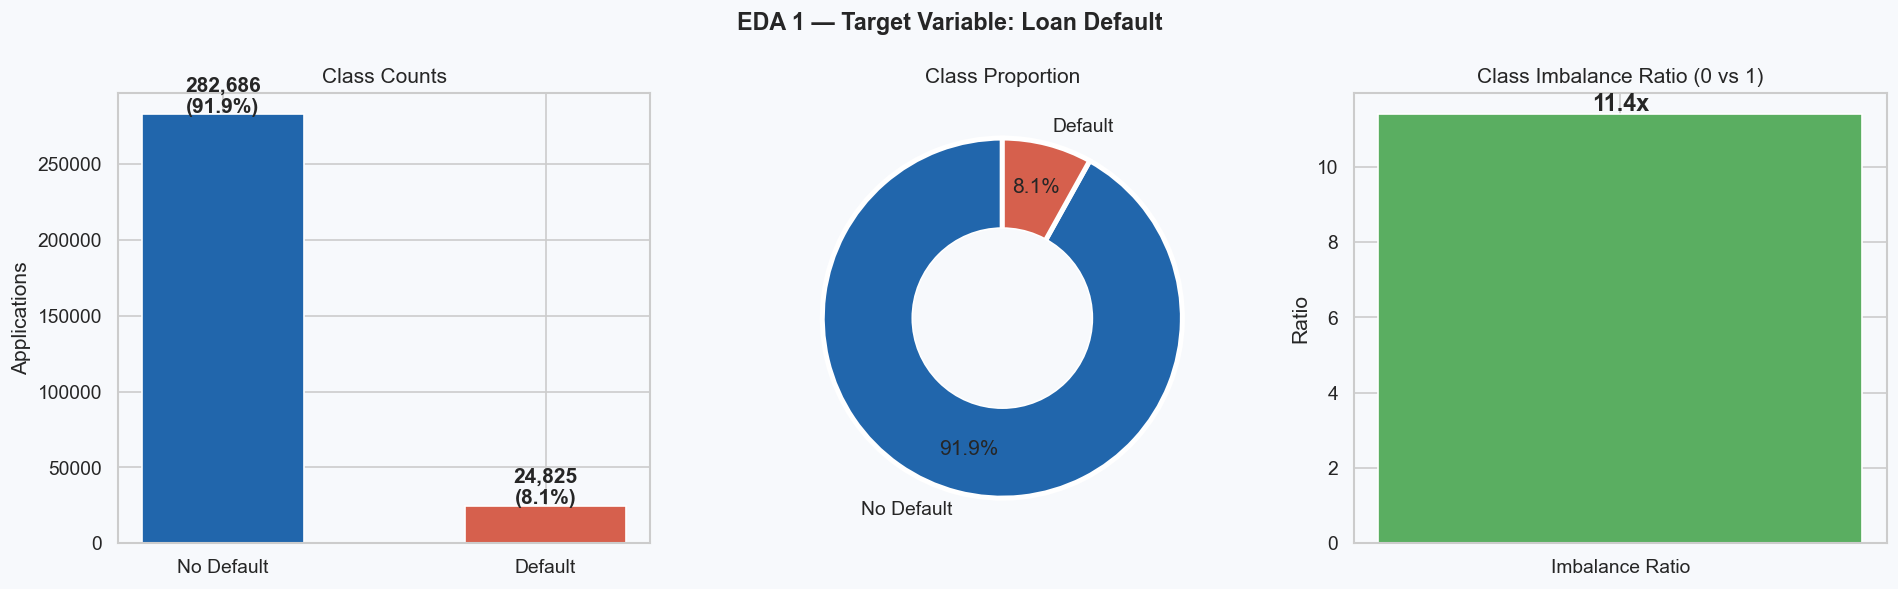

▶  EDA 2: Demographics


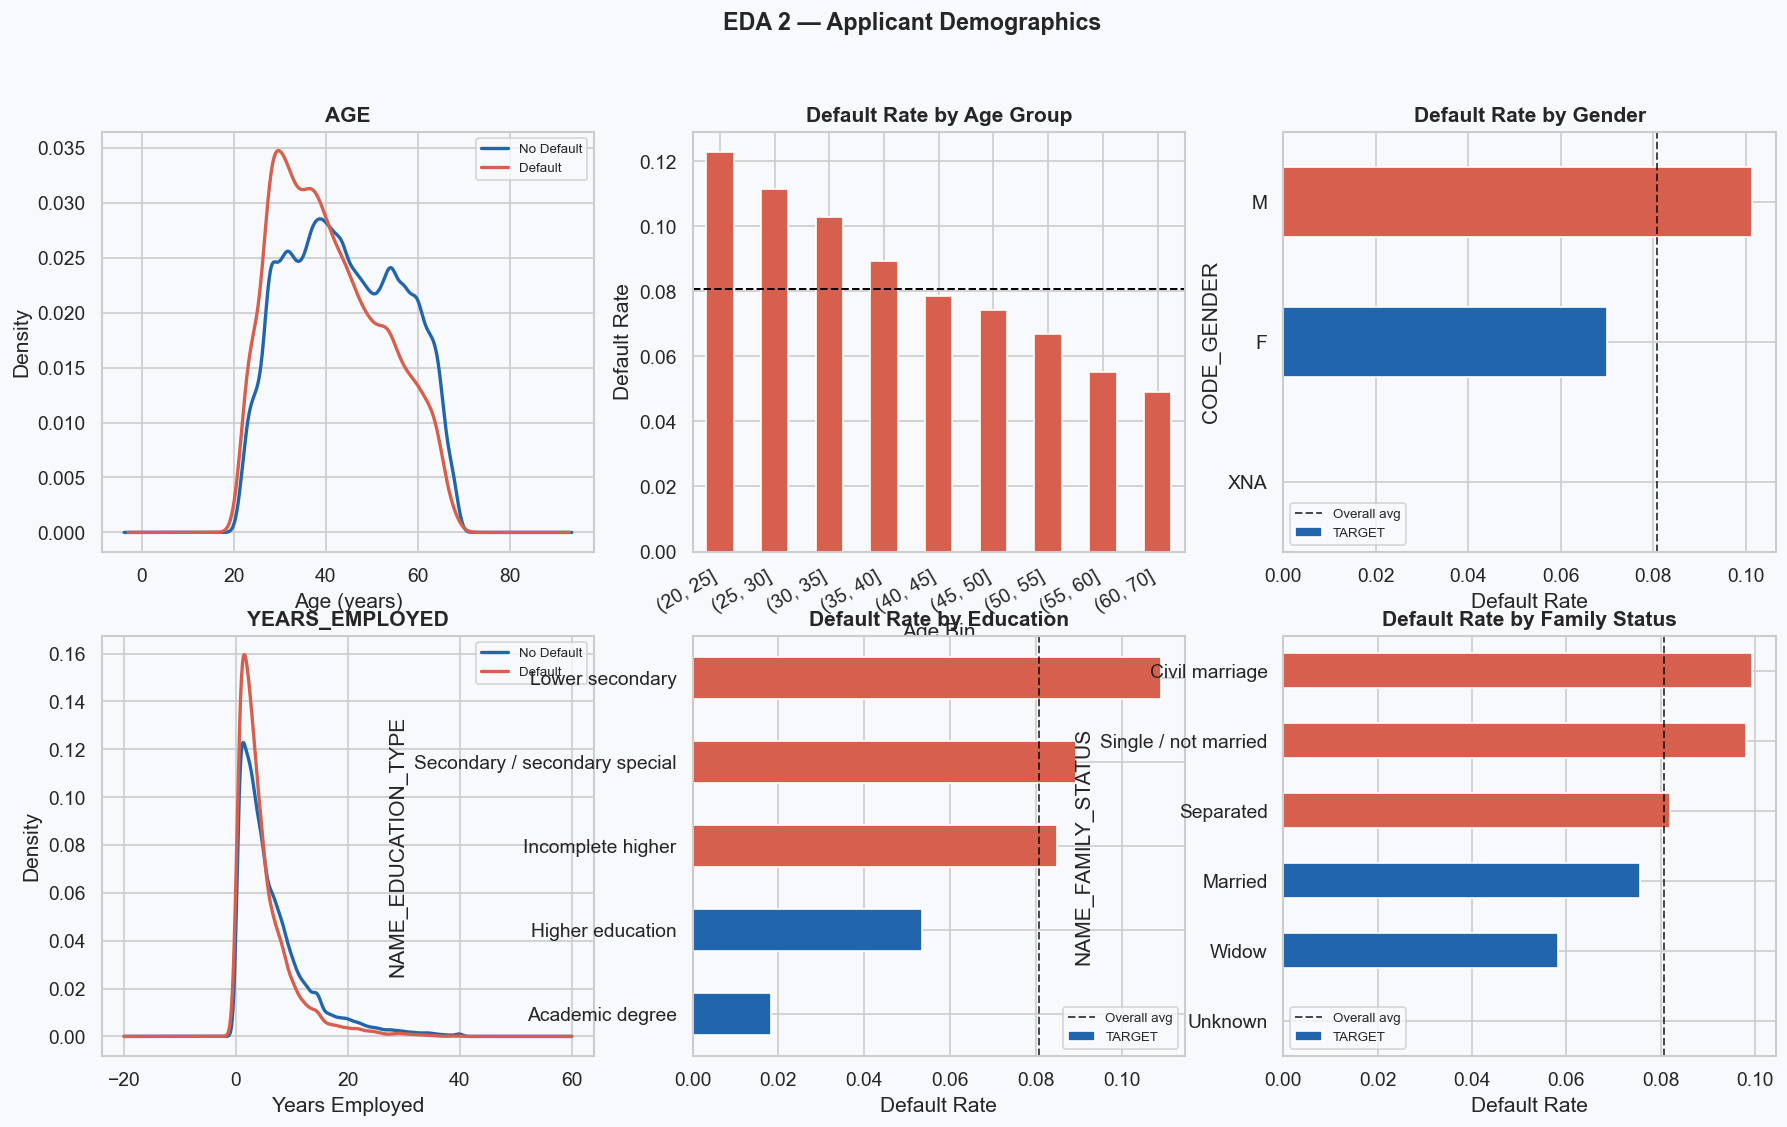

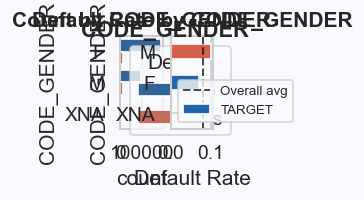

▶  EDA 3: Income, Credit, Annuity


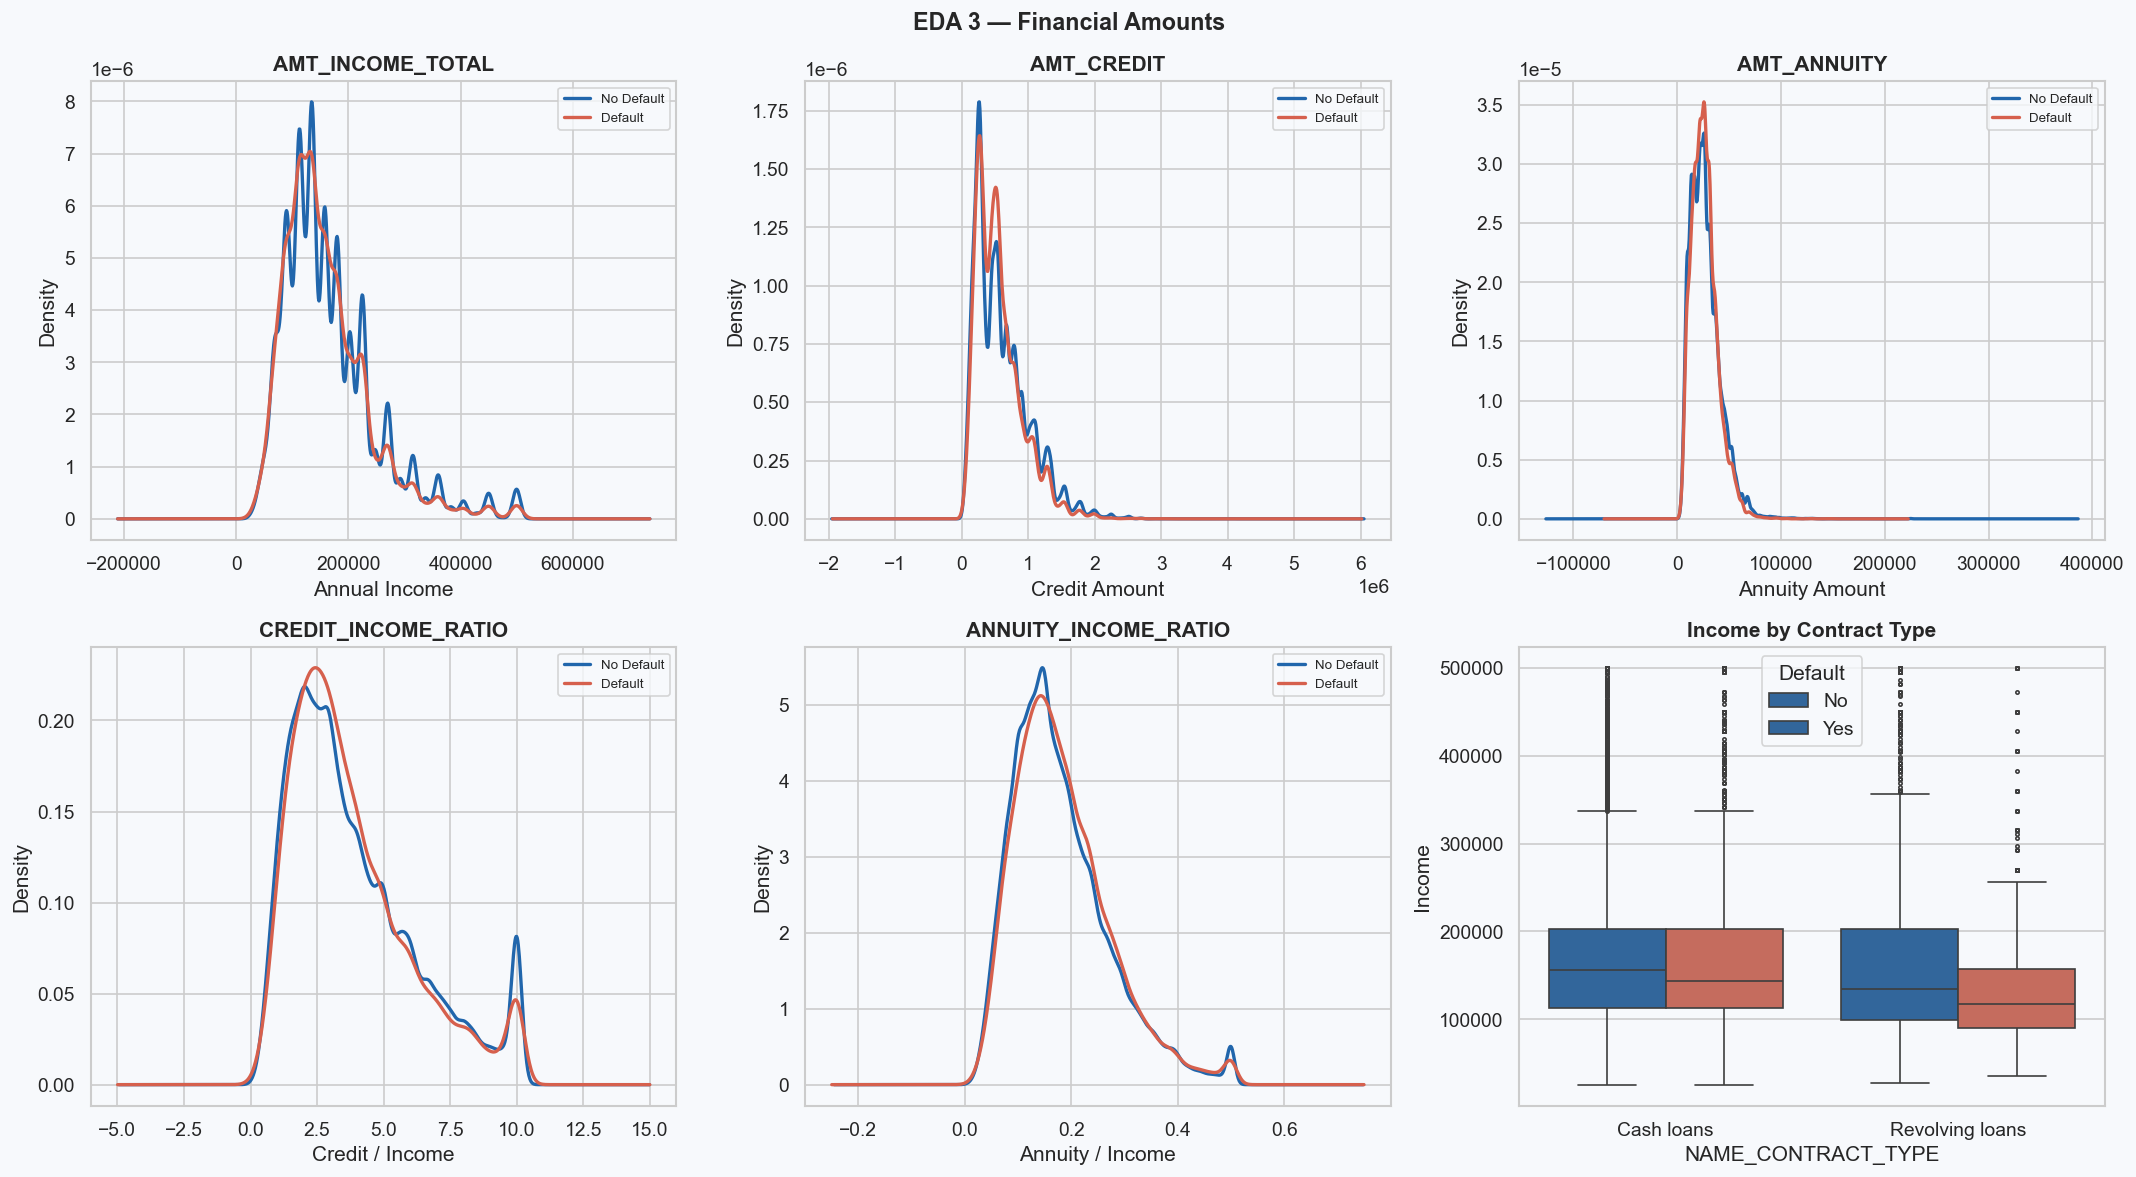

▶  EDA 4: External Sources


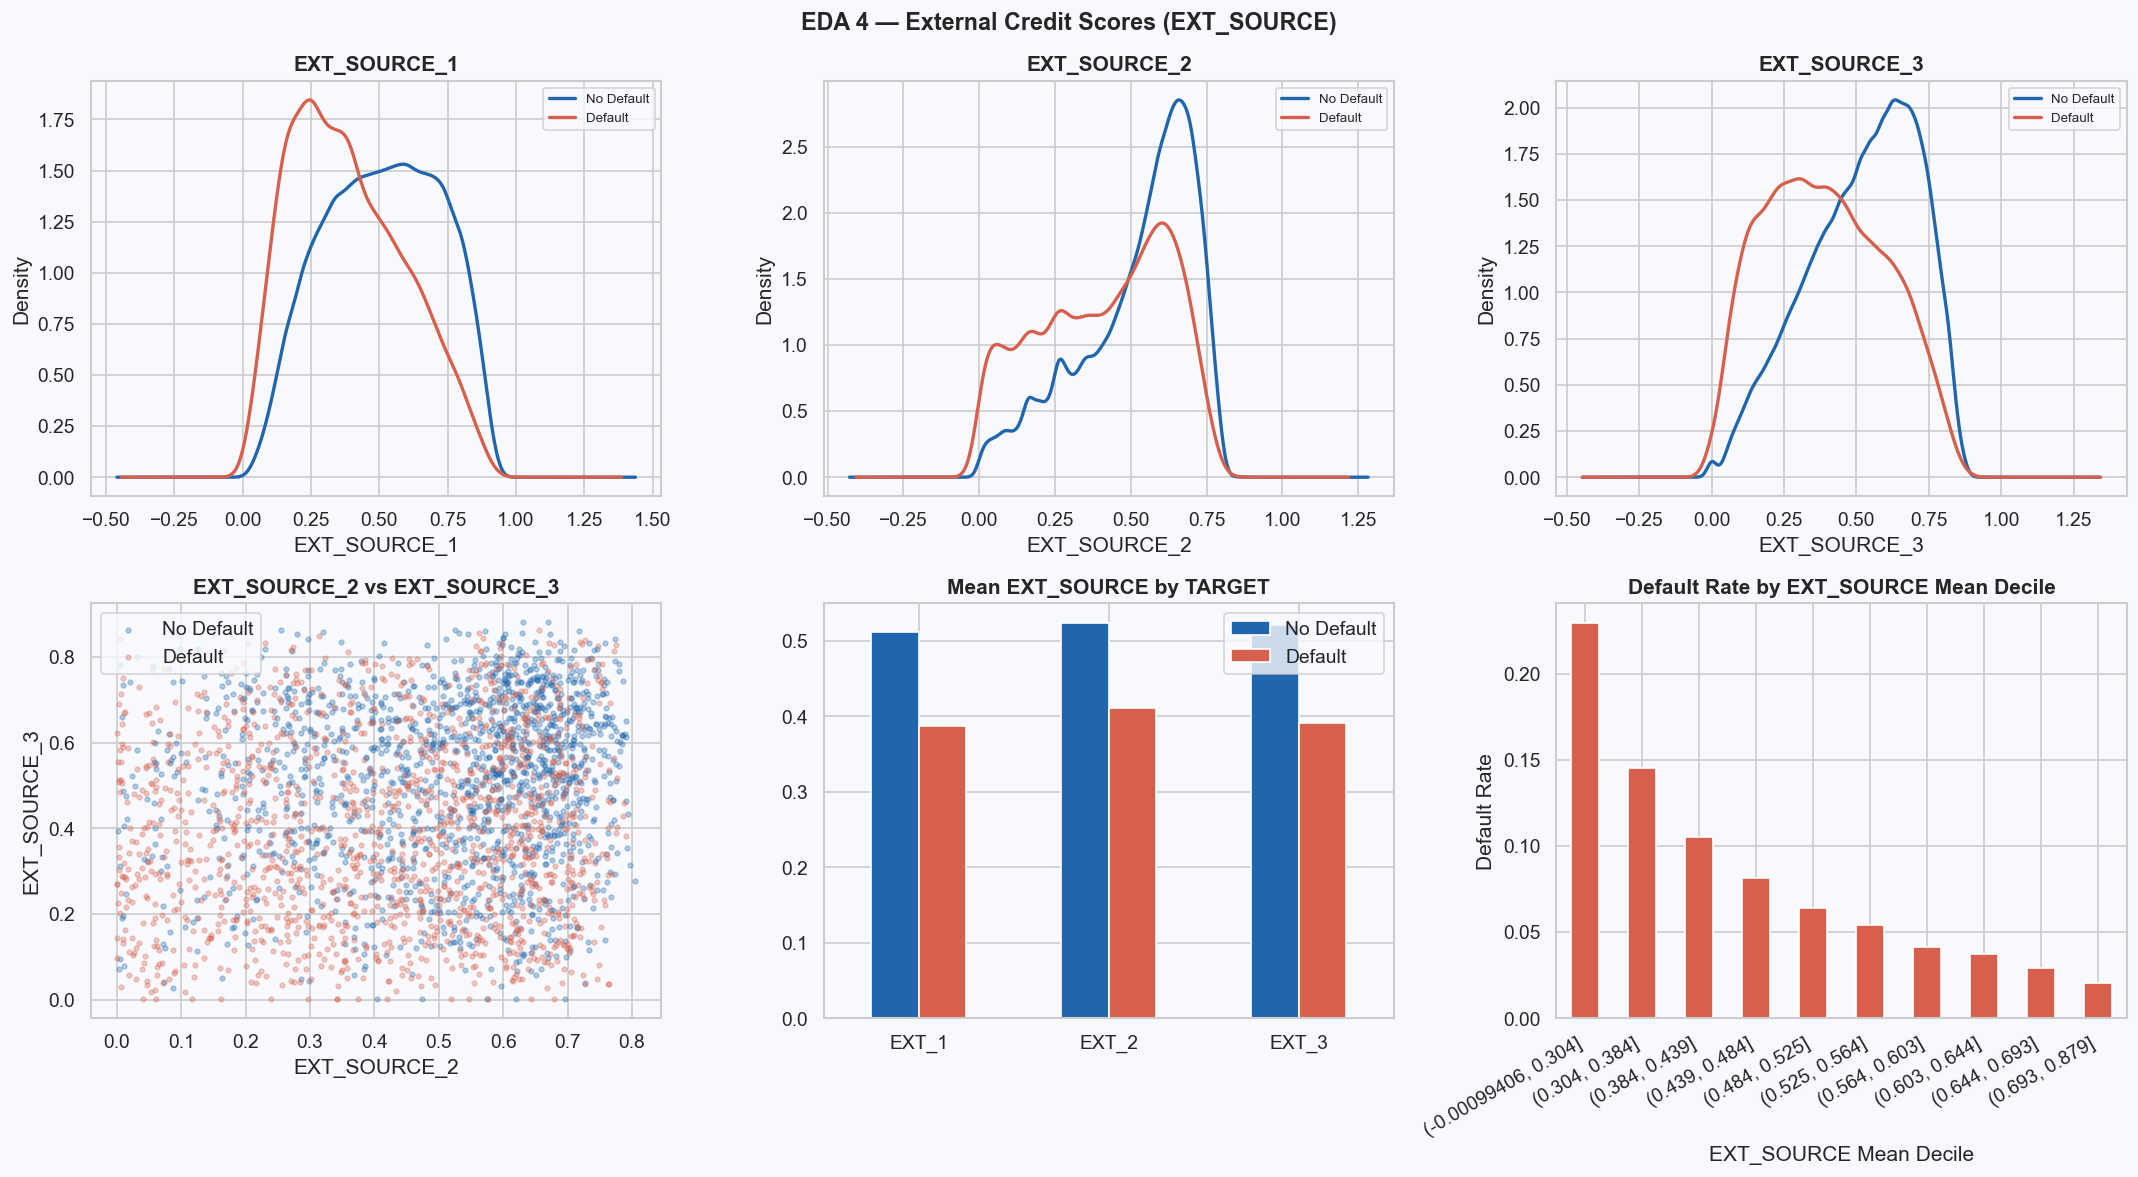

▶  EDA 5: Categorical features


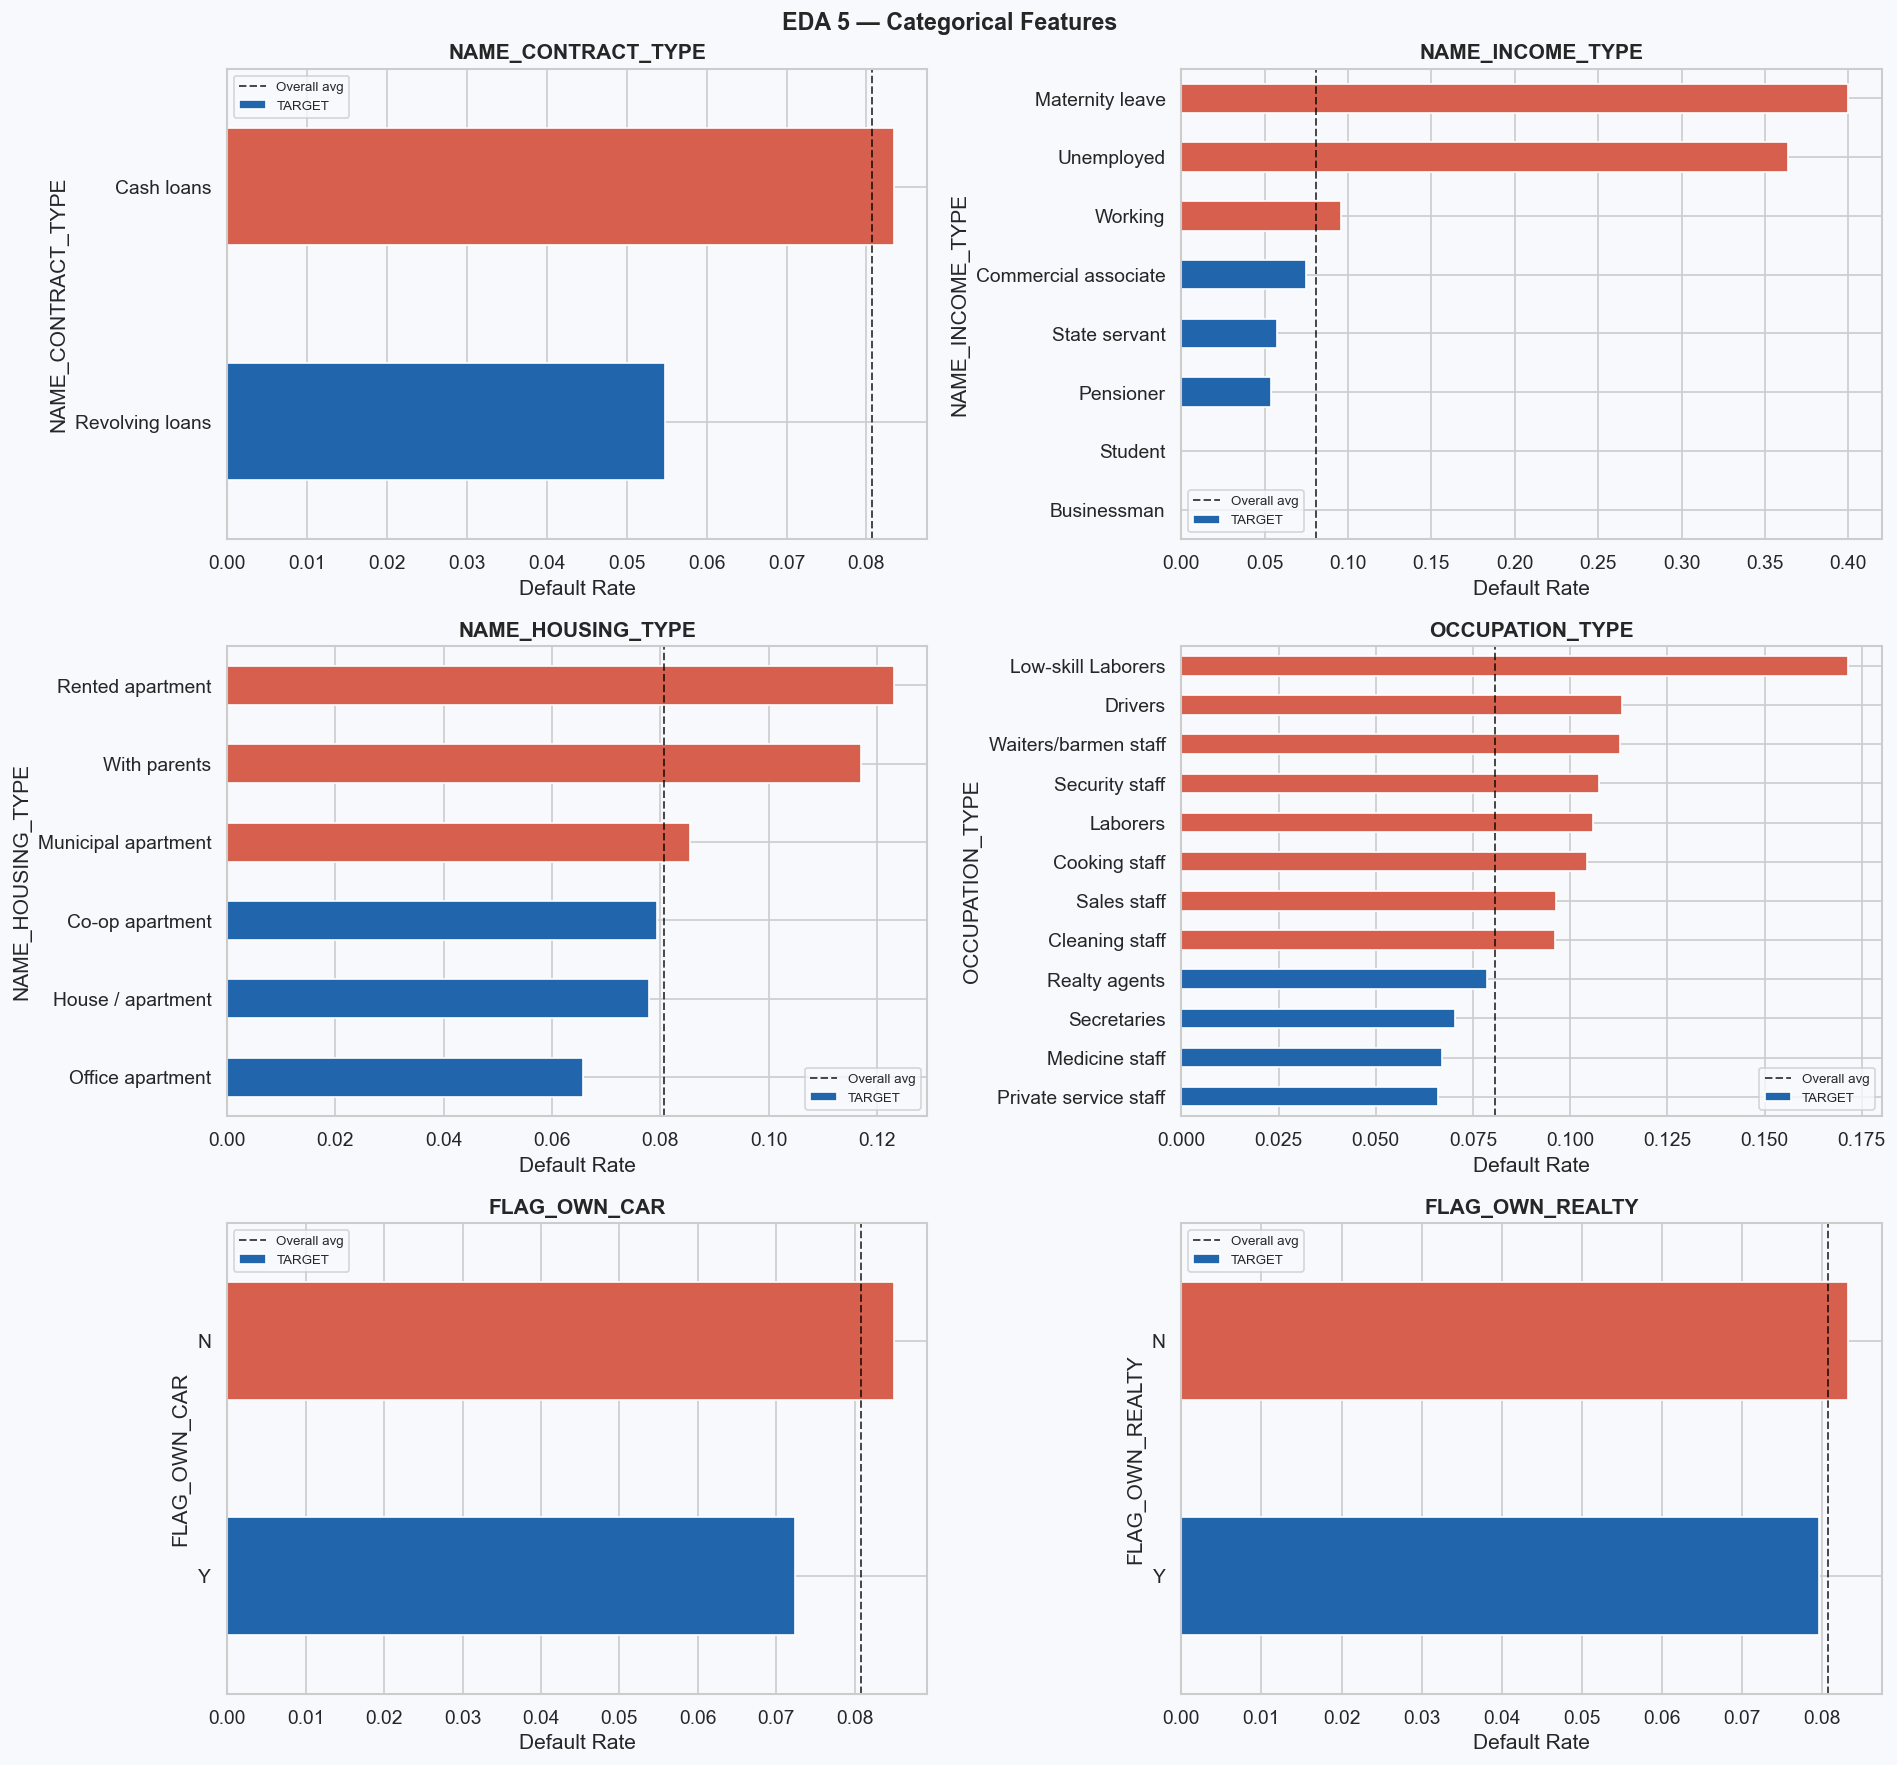

▶  EDA 6: Document flags & social surroundings


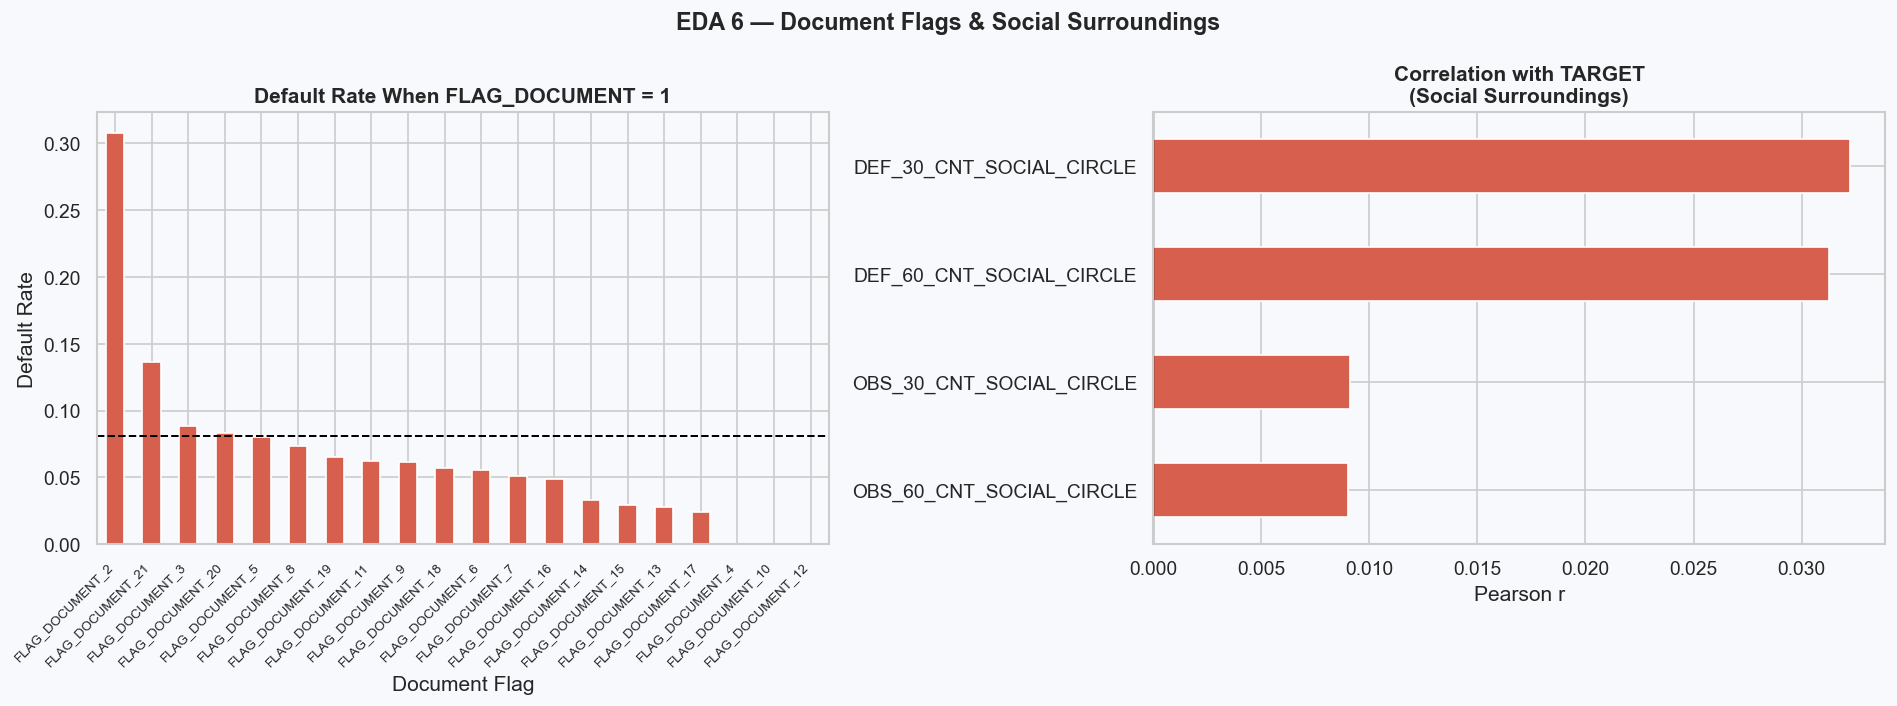

▶  EDA 7: Bureau


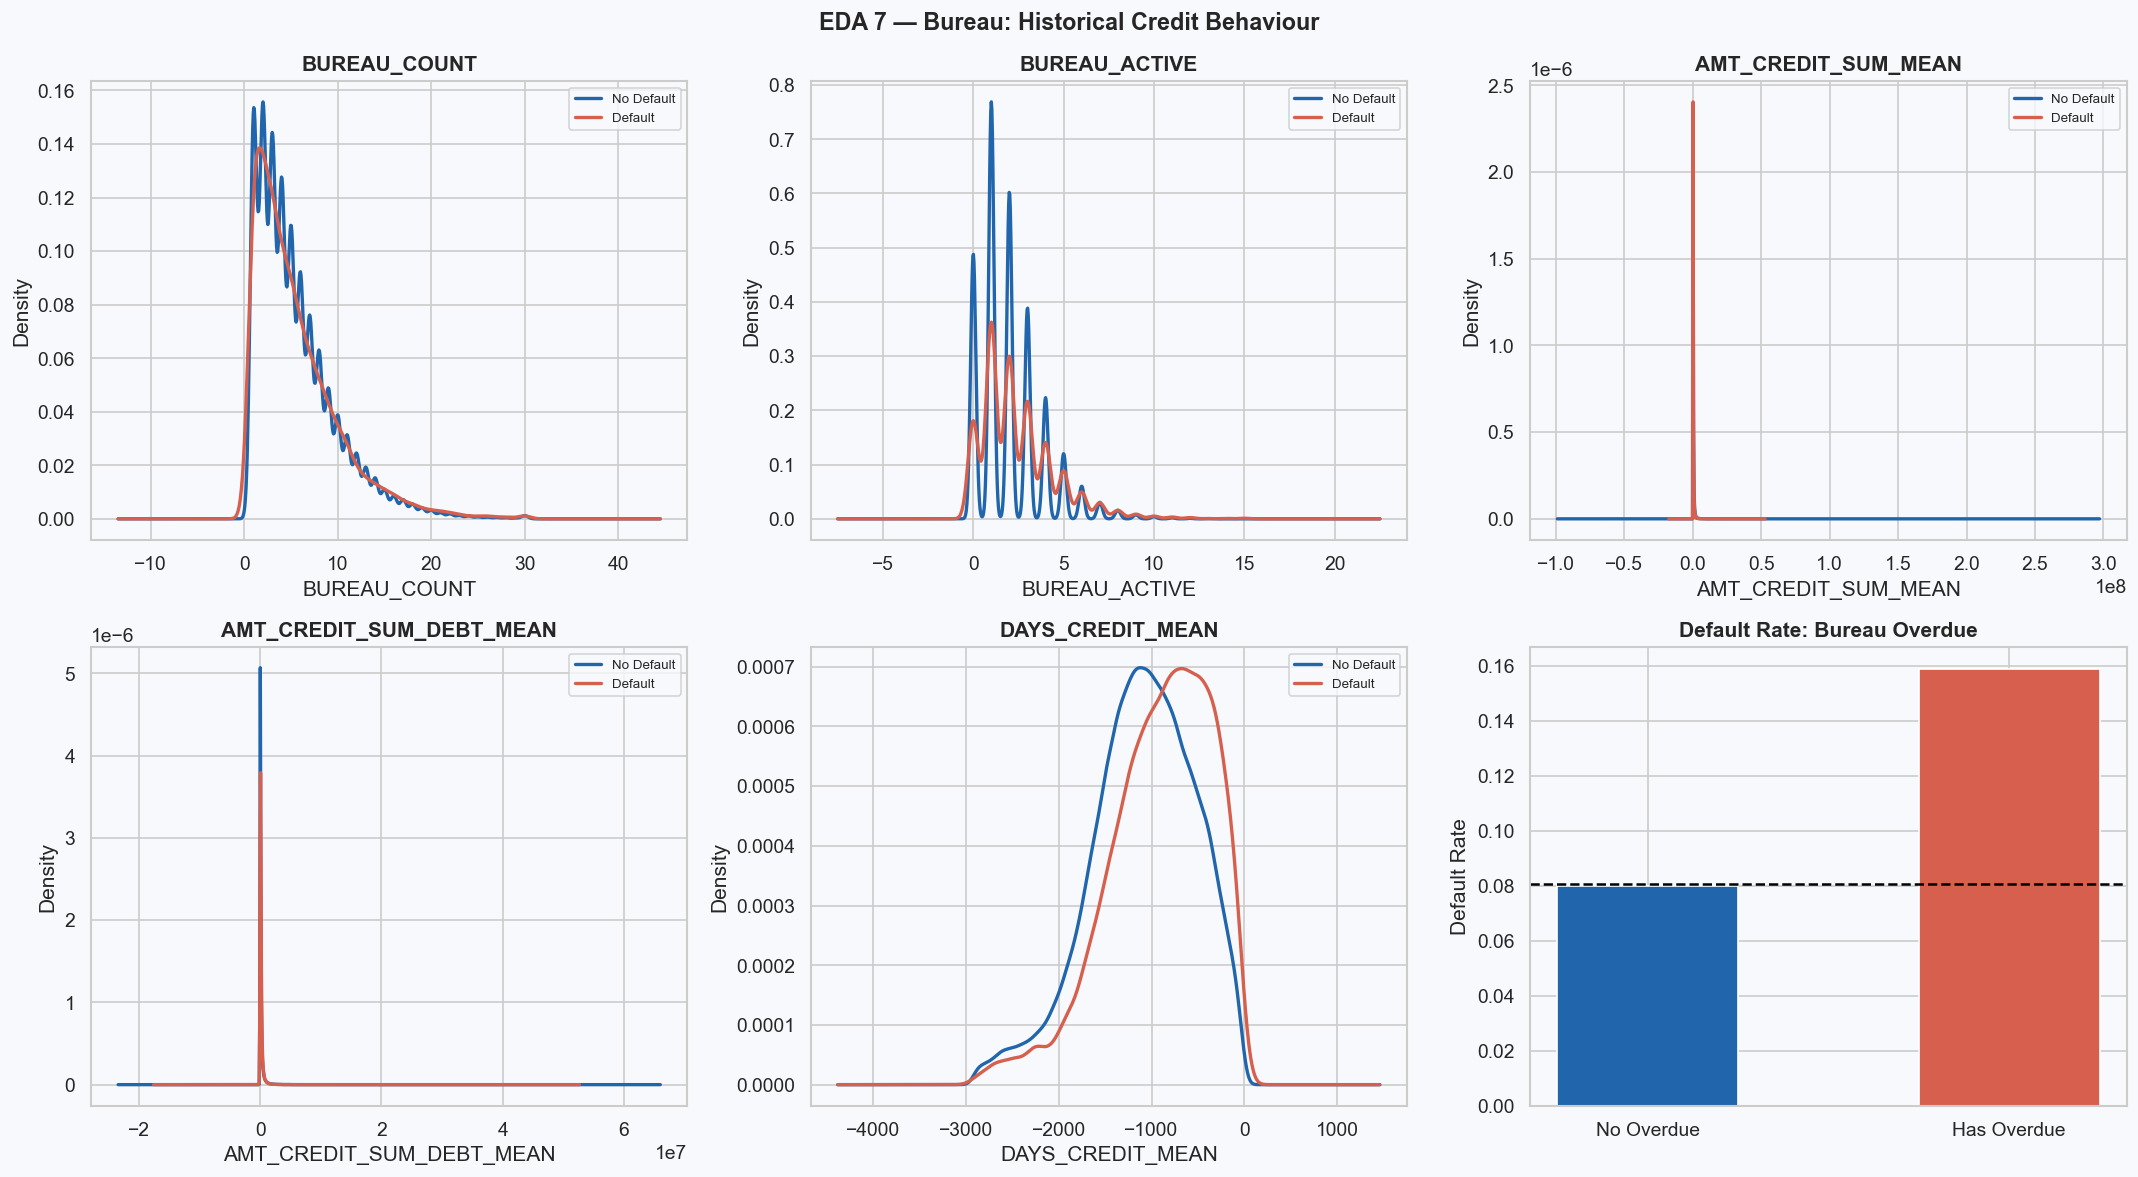

▶  EDA 8: Previous applications


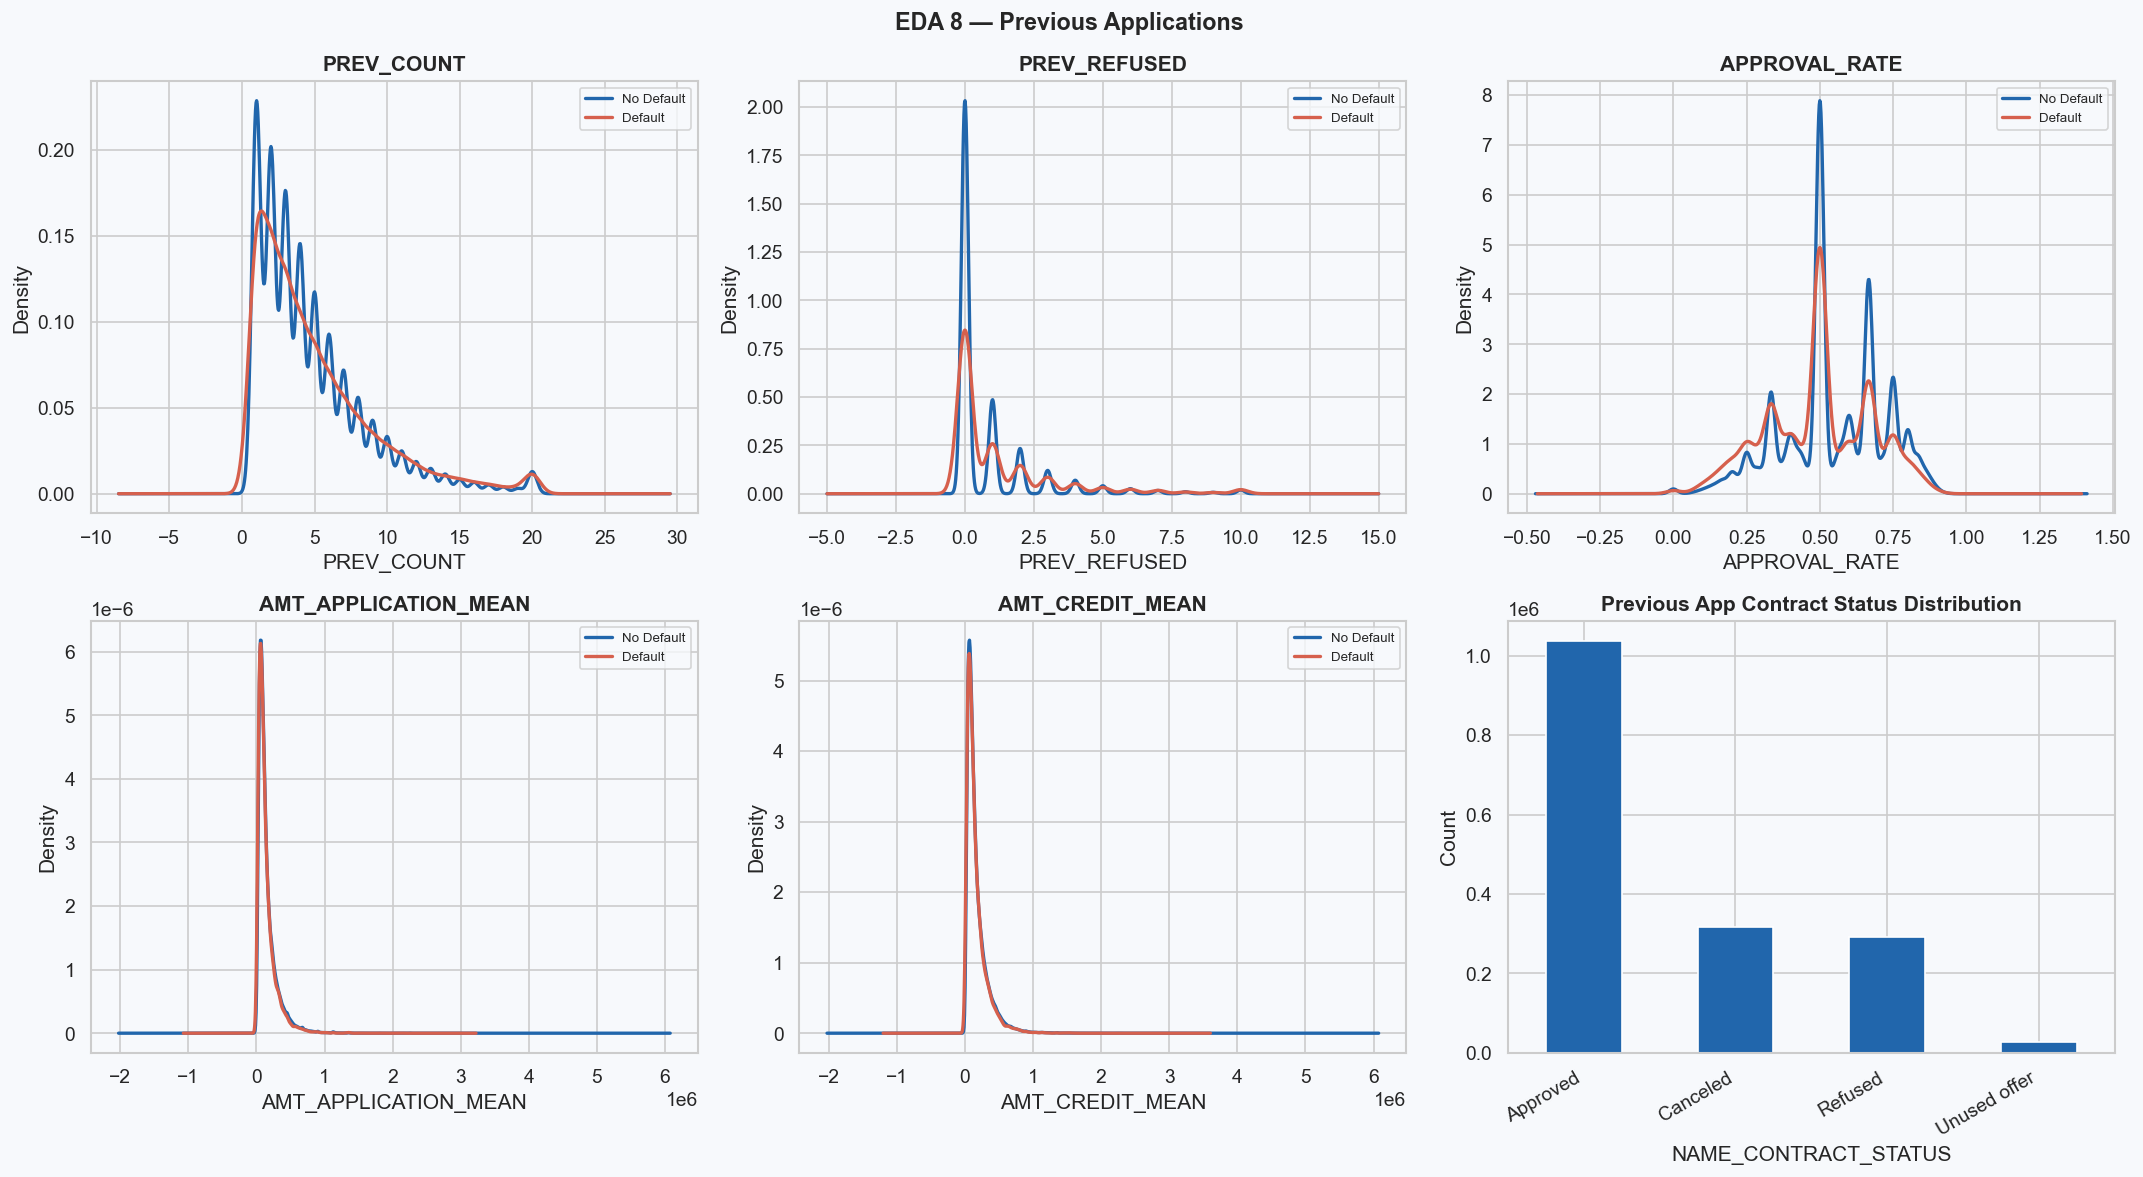

▶  EDA 9: Installment payments


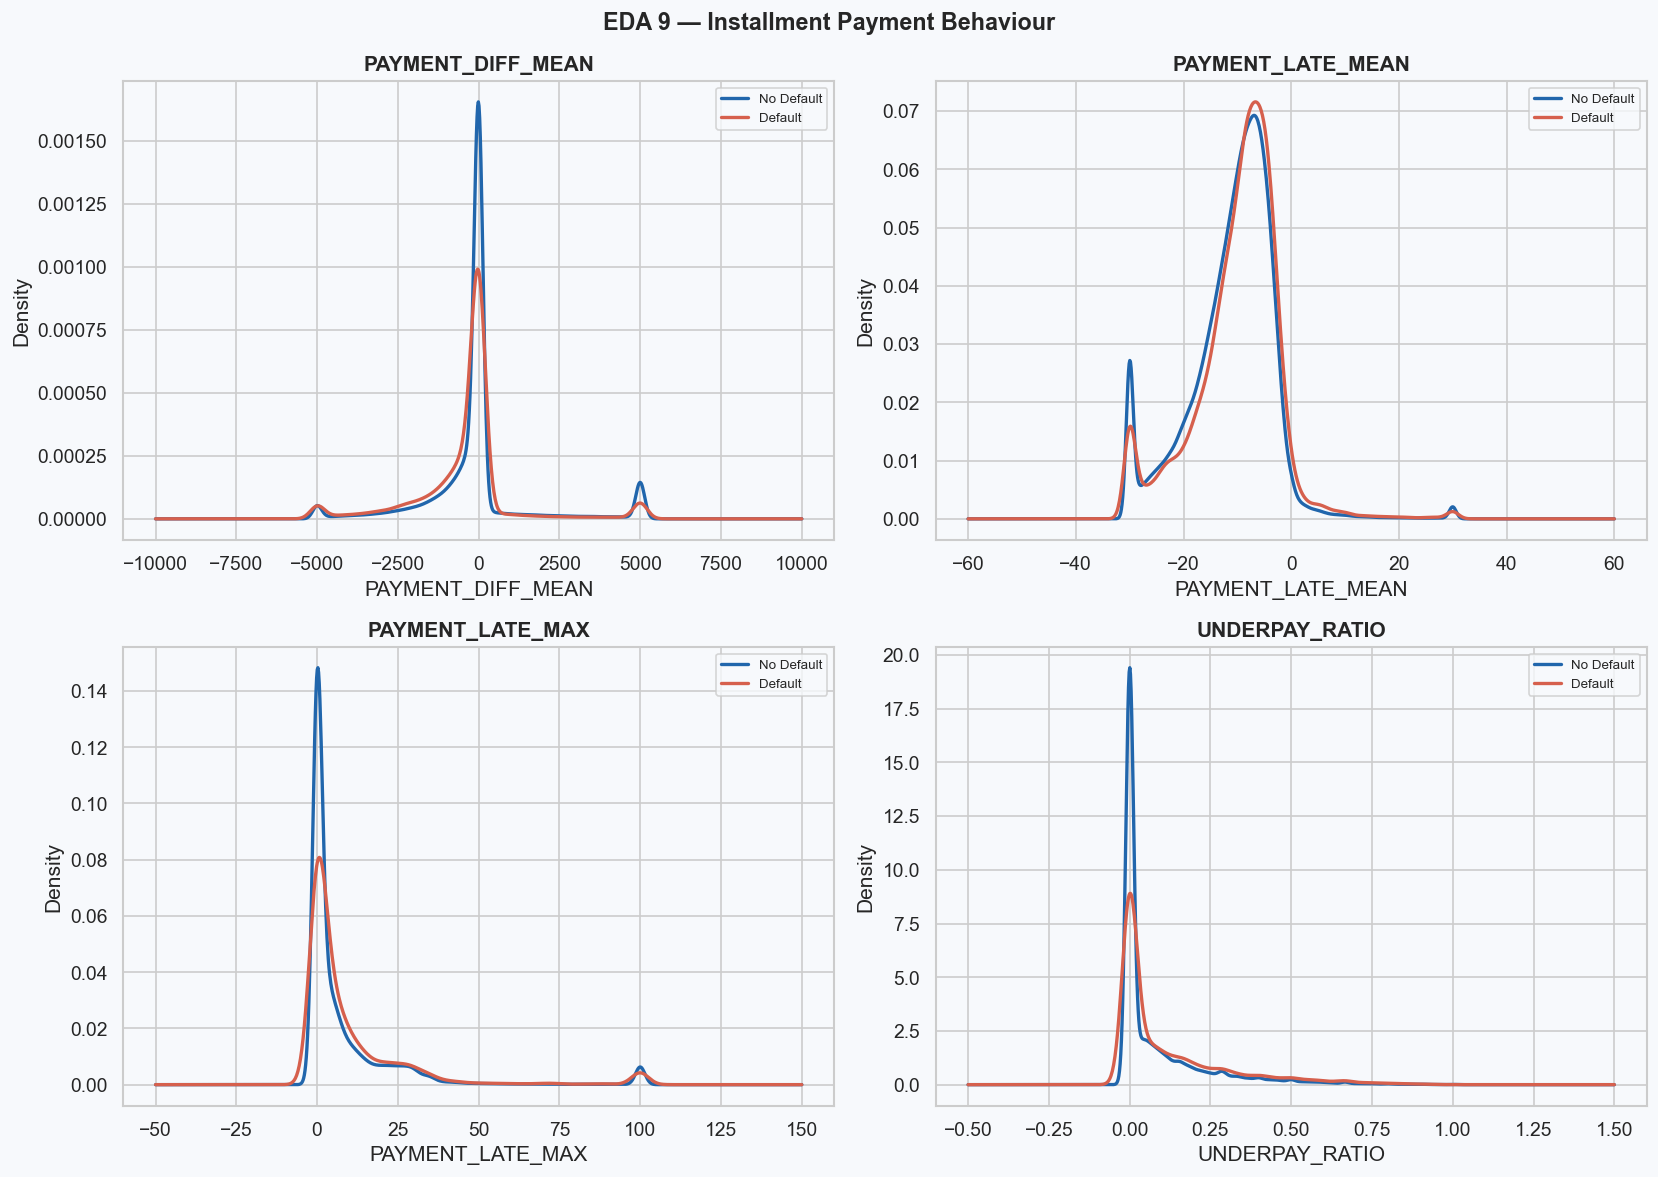

▶  EDA 10: POS Cash & Credit Card Balance


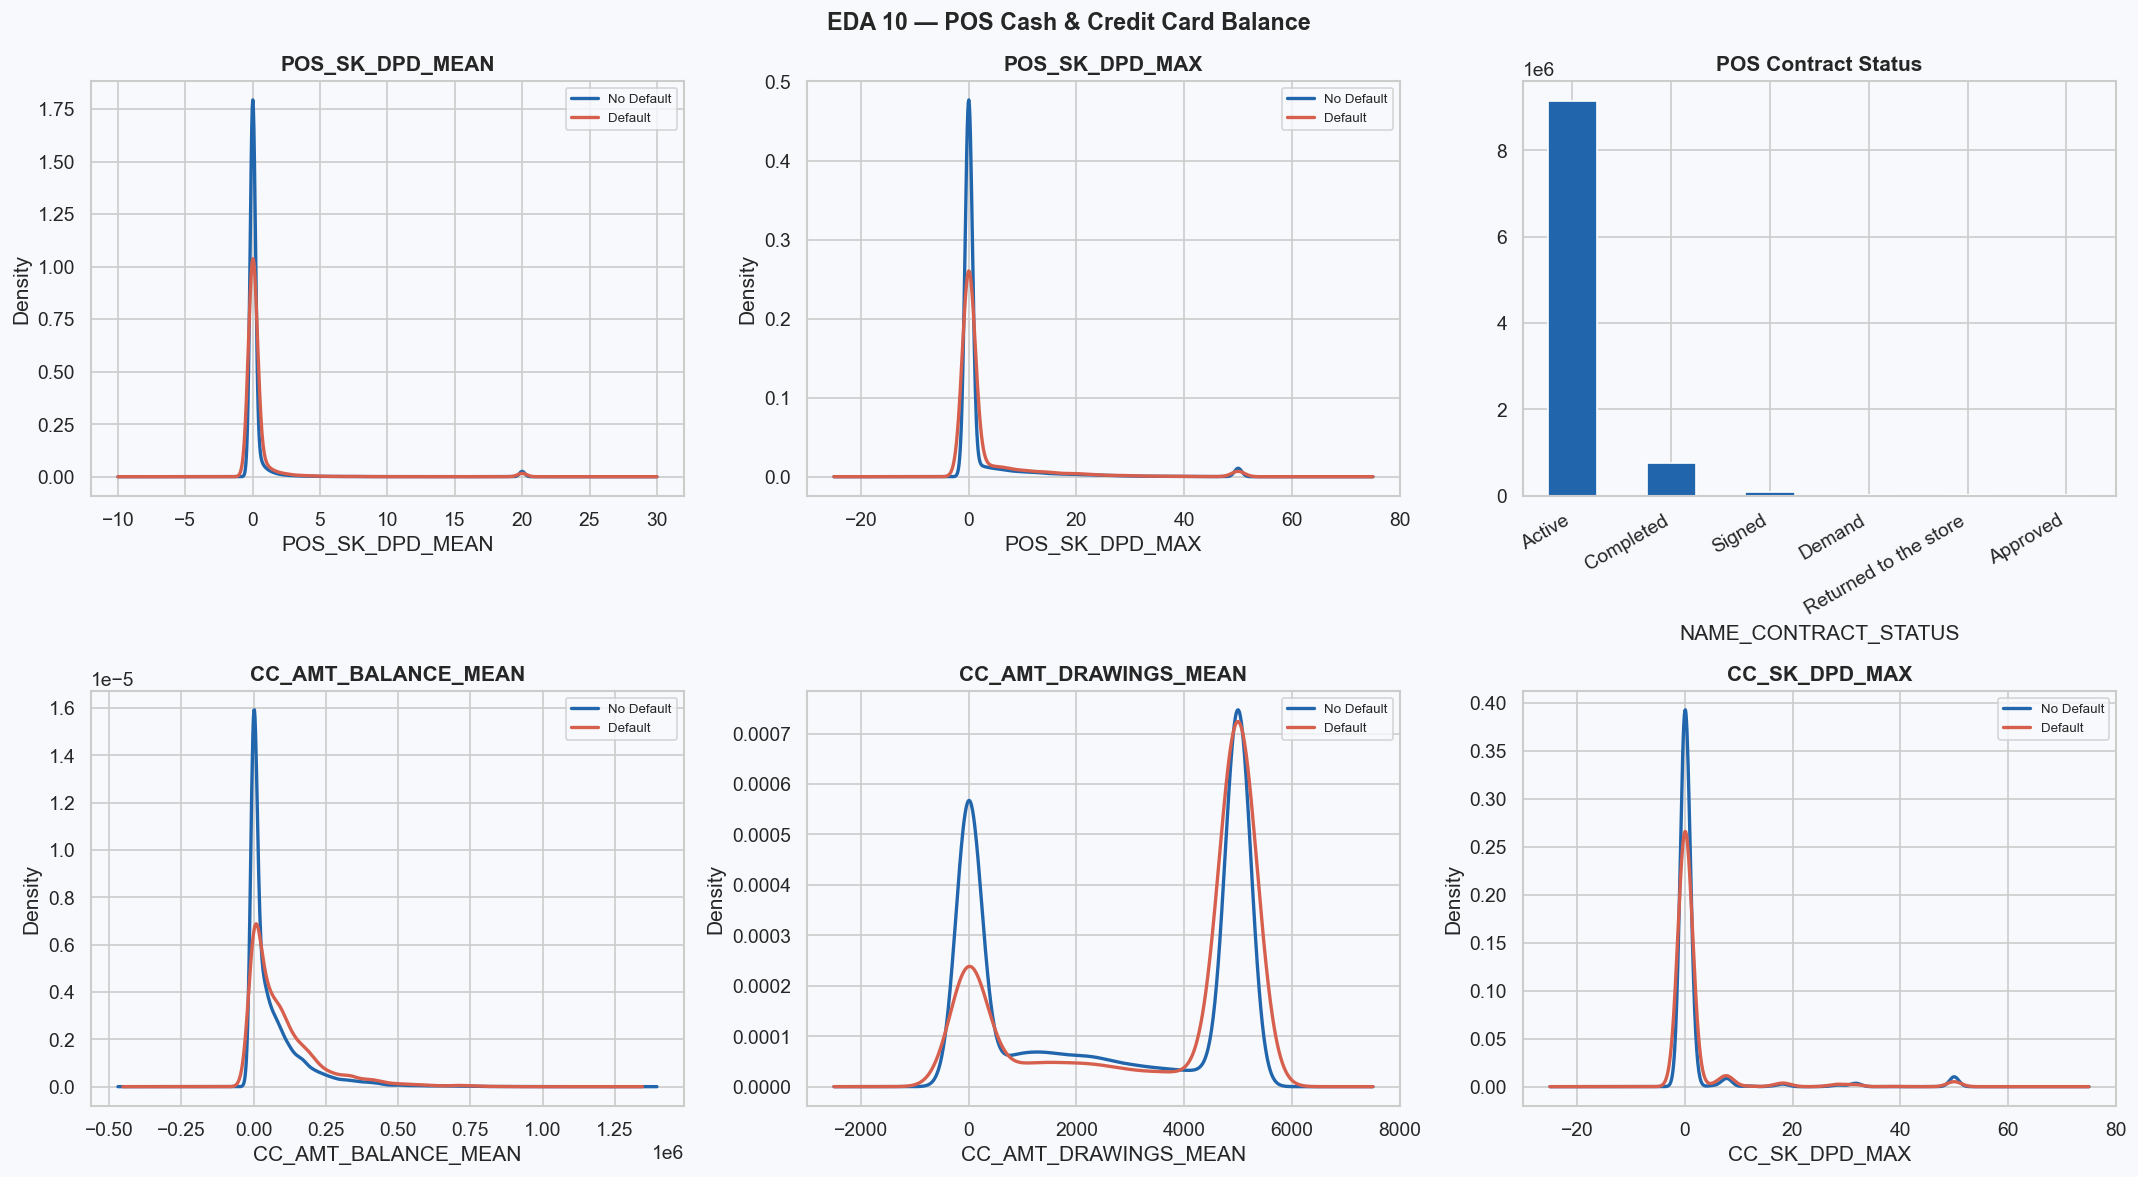

▶  EDA 11: Full correlation heatmap


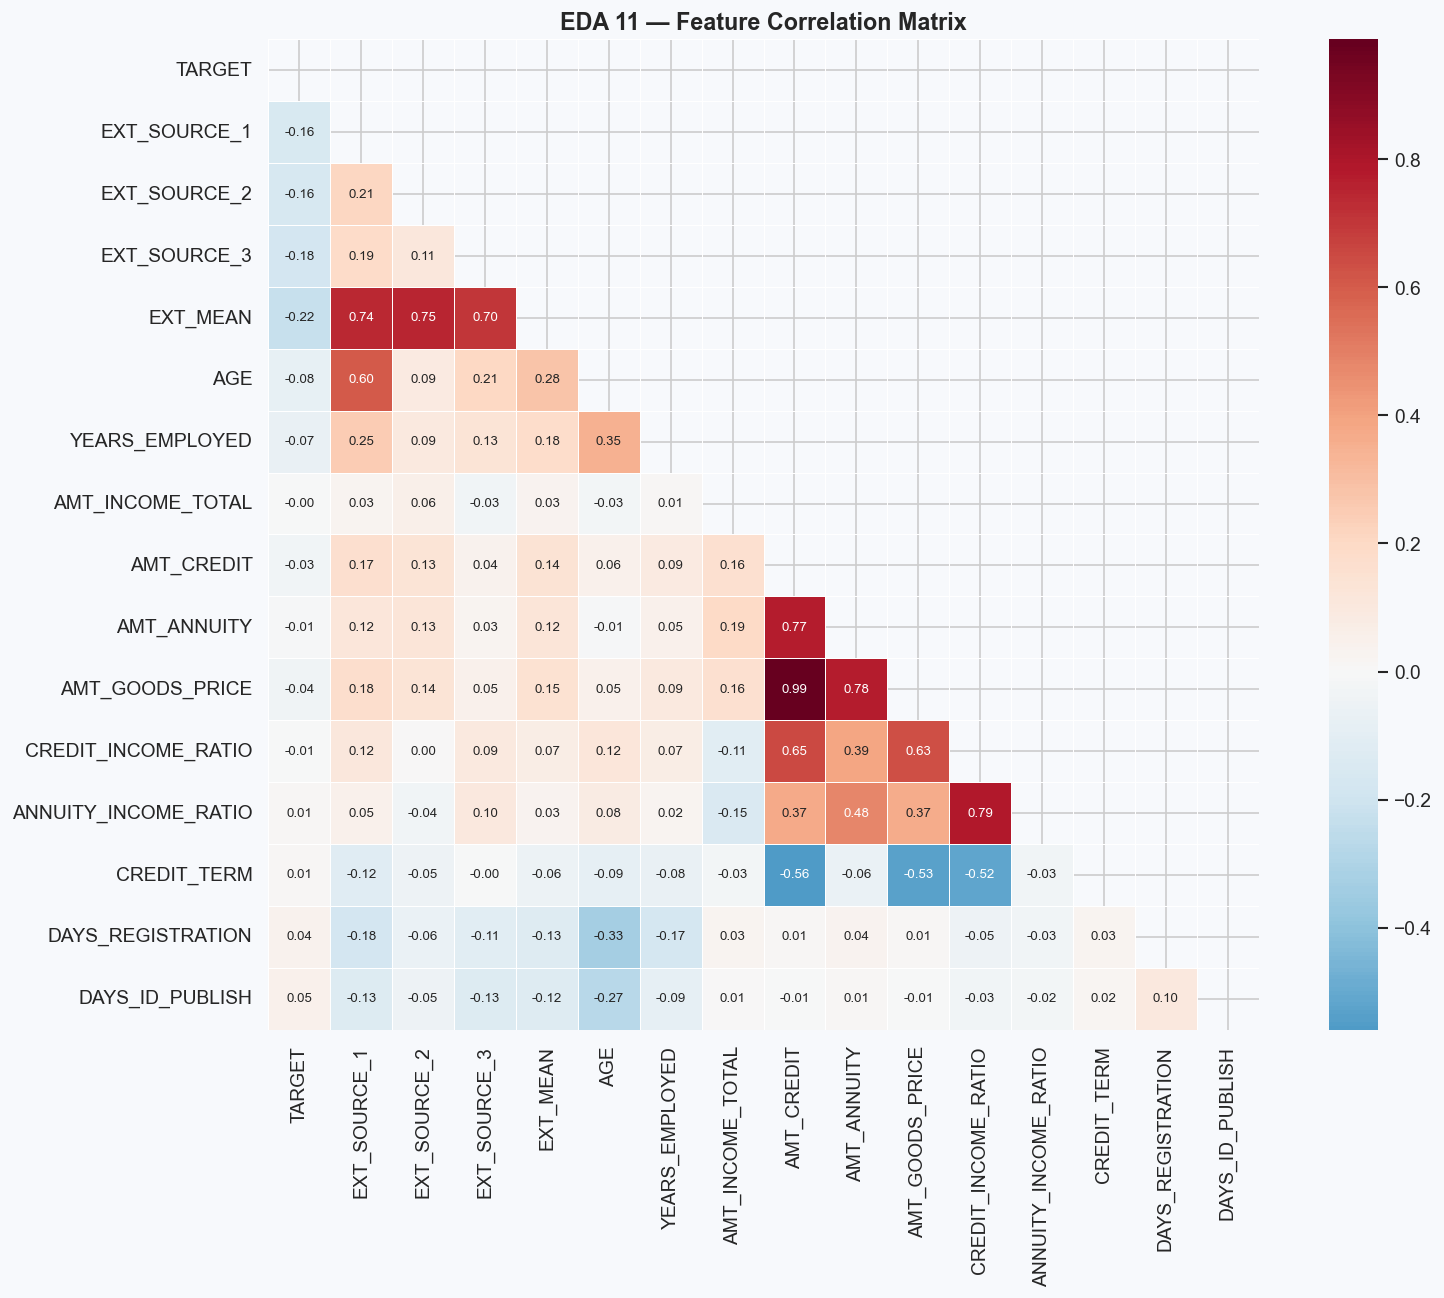

▶  EDA 12: Outlier analysis

Outlier Summary (IQR method):
                             Q1         Q3        IQR  Outliers  Outlier %
Feature                                                                   
AMT_INCOME_TOTAL      112500.00  202500.00   90000.00     14035       4.56
AMT_CREDIT            270000.00  808650.00  538650.00      6562       2.13
AMT_ANNUITY            16524.00   34596.00   18072.00      7504       2.44
CREDIT_INCOME_RATIO        2.02       5.16       3.14     11493       3.74
ANNUITY_INCOME_RATIO       0.11       0.23       0.11      7878       2.56
AGE                       34.01      53.92      19.92         0       0.00
YEARS_EMPLOYED             2.10       8.70       6.60     15149       4.93
EXT_SOURCE_1               0.33       0.68       0.34         0       0.00
EXT_SOURCE_2               0.39       0.66       0.27         0       0.00
EXT_SOURCE_3               0.37       0.67       0.30         0       0.00


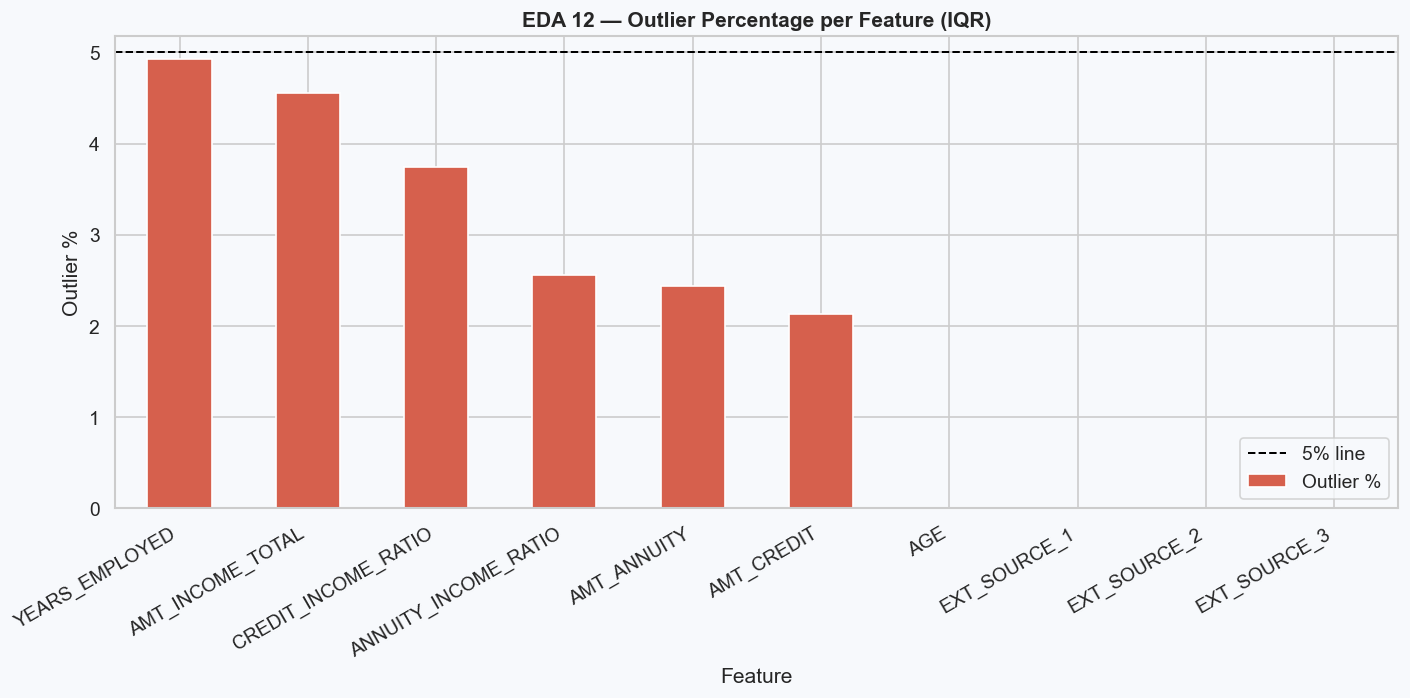

▶  EDA 13: Multivariate analysis


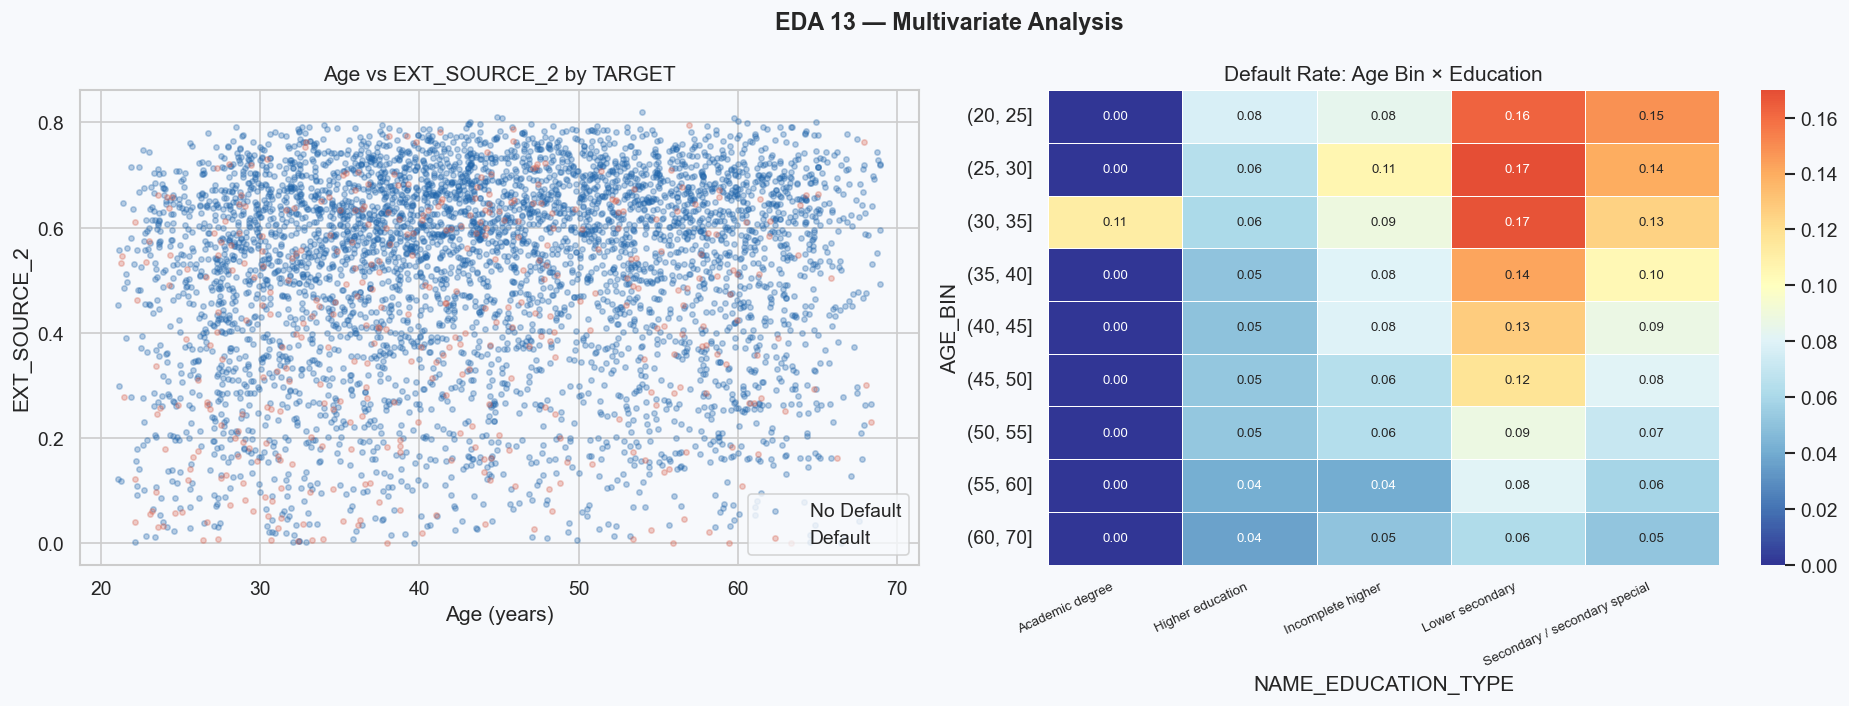


  EDA COMPLETE — Key Findings
  [Imbalance      ] Dataset is ~91.9% non-default; handle with class weighting or SMOTE.
  [Age            ] Younger applicants (20-30) default more; risk decreases steadily with age.
  [EXT_SOURCE     ] EXT_SOURCE_2 & _3 are the strongest single predictors (negative corr).
  [Employment     ] DAYS_EMPLOYED has 365,243 anomalies (likely 'not employed'); replace with NaN.
  [Credit ratio   ] High Credit-to-Income ratio correlates positively with default.
  [Bureau         ] More active bureau credits and overdue history ↑ default risk.
  [Prev. apps     ] Higher refusal count and lower approval rate ↑ default risk.
  [Installments   ] Late payments and under-payments are strong default indicators.
  [DPD            ] SK_DPD (days past due) in POS/CC tables strongly signals default.
  [Gender         ] Males default more than females on average.
  [Education      ] Lower secondary education ↑ default; academic degree ↓ default.
  [Occupation     ] Low-skill

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': '#F7F9FC',
    'axes.facecolor':   '#F7F9FC',
    'axes.edgecolor':   '#CCCCCC',
    'figure.dpi':       120,
})

C0, C1 = '#2166AC', '#D6604D'   # blue = no default, red = default
CMAP   = 'RdBu_r'

# ============================================================
# 0. LOAD DATA
# ============================================================
BASE = "/Users/elina/Downloads/home-credit-default-risk (1)/"

app_train  = pd.read_csv(BASE + "application_train.csv")
app_test   = pd.read_csv(BASE + "application_test.csv")
bureau     = pd.read_csv(BASE + "bureau.csv")
bureau_bal = pd.read_csv(BASE + "bureau_balance.csv")
cc_bal     = pd.read_csv(BASE + "credit_card_balance.csv")
inst_pay   = pd.read_csv(BASE + "installments_payments.csv")
pos_cash   = pd.read_csv(BASE + "POS_CASH_balance.csv")
prev_app   = pd.read_csv(BASE + "previous_application.csv")

# ── Derived columns used throughout ─────────────────────────
app_train['AGE']            = app_train['DAYS_BIRTH'].abs() / 365
app_train['YEARS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan).abs() / 365
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / (app_train['AMT_INCOME_TOTAL'] + 1)
app_train['ANNUITY_INCOME_RATIO']= app_train['AMT_ANNUITY'] / (app_train['AMT_INCOME_TOTAL'] + 1)
app_train['CREDIT_TERM']         = app_train['AMT_ANNUITY'] / (app_train['AMT_CREDIT'] + 1)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save(fname):
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


def default_rate_bar(col, df=app_train, ax=None, topn=10, title=None):
    """Horizontal bar: default rate per category, sorted descending."""
    dr = (df.groupby(col)['TARGET'].mean()
            .sort_values(ascending=True)
            .tail(topn))
    colors = [C1 if v > df['TARGET'].mean() else C0 for v in dr.values]
    ax = ax or plt.gca()
    dr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(df['TARGET'].mean(), color='black', linestyle='--',
               linewidth=1.2, alpha=0.7, label='Overall avg')
    ax.set_xlabel('Default Rate')
    ax.set_title(title or col, fontweight='bold')
    ax.legend(fontsize=8)


def kde_by_target(col, df=app_train, ax=None, xlabel=None, clip=None):
    """KDE of a numeric column split by TARGET."""
    ax = ax or plt.gca()
    for val, color, label in [(0, C0, 'No Default'), (1, C1, 'Default')]:
        data = df.loc[df['TARGET'] == val, col].dropna()
        if clip:
            data = data.clip(*clip)
        data.plot(kind='kde', ax=ax, color=color, linewidth=2, label=label)
    ax.set_xlabel(xlabel or col)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)


def plot_count_and_rate(col, df=app_train, figsize=(13, 5), topn=12, title=None):
    """Side-by-side: value counts + default rate per category."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    order = df[col].value_counts().head(topn).index
    sns.countplot(data=df, y=col, order=order, palette=[C0, C1],
                  hue='TARGET', ax=axes[0])
    axes[0].set_title(f'Count by {col}', fontweight='bold')
    axes[0].legend(title='Default', labels=['No','Yes'])

    default_rate_bar(col, df=df, ax=axes[1], topn=topn,
                     title=f'Default Rate by {col}')
    fig.suptitle(title or col, fontsize=13, fontweight='bold', y=1.01)
    return fig, axes


# ============================================================
# EDA 1 — TARGET DISTRIBUTION (imbalance deep-dive)
# ============================================================
print("▶  EDA 1: Target distribution")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EDA 1 — Target Variable: Loan Default", fontsize=14, fontweight='bold')

# Count
tc = app_train['TARGET'].value_counts()
axes[0].bar(['No Default','Default'], tc.values, color=[C0, C1], edgecolor='white', width=0.5)
for i, v in enumerate(tc.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(app_train)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Applications")

# Donut
axes[1].pie(tc.values, labels=['No Default','Default'],
            autopct='%1.1f%%', colors=[C0, C1],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':3},
            pctdistance=0.75)
centre = plt.Circle((0,0), 0.5, fc='#F7F9FC')
axes[1].add_artist(centre)
axes[1].set_title("Class Proportion")

# Imbalance ratio
axes[2].bar(['Imbalance Ratio'], [tc[0]/tc[1]], color='#5AAE61', edgecolor='white', width=0.4)
axes[2].text(0, tc[0]/tc[1]+0.1, f'{tc[0]/tc[1]:.1f}x', ha='center', fontsize=14, fontweight='bold')
axes[2].set_title("Class Imbalance Ratio (0 vs 1)")
axes[2].set_ylabel("Ratio")

save("eda_01_target.png")


# ============================================================
# EDA 2 — APPLICANT DEMOGRAPHICS
# ============================================================
print("▶  EDA 2: Demographics")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 2 — Applicant Demographics", fontsize=14, fontweight='bold')

# Age distribution
kde_by_target('AGE', ax=axes[0][0], xlabel='Age (years)')

# Age bins default rate
app_train['AGE_BIN'] = pd.cut(app_train['AGE'], bins=[20,25,30,35,40,45,50,55,60,70])
dr_age = app_train.groupby('AGE_BIN')['TARGET'].mean()
dr_age.plot(kind='bar', ax=axes[0][1], color=C1, edgecolor='white')
axes[0][1].axhline(app_train['TARGET'].mean(), color='black', linestyle='--', linewidth=1.2)
axes[0][1].set_title("Default Rate by Age Group", fontweight='bold')
axes[0][1].set_xlabel("Age Bin"); axes[0][1].set_ylabel("Default Rate")
plt.setp(axes[0][1].get_xticklabels(), rotation=30, ha='right')

# Gender
plot_count_and_rate('CODE_GENDER', figsize=(1,1))   # placeholder — done inline below
axes[0][2].remove()
ax_tmp = fig.add_subplot(2, 3, 3)
default_rate_bar('CODE_GENDER', ax=ax_tmp, title='Default Rate by Gender')

# Employment years KDE
kde_by_target('YEARS_EMPLOYED', ax=axes[1][0], xlabel='Years Employed', clip=(0,40))

# Education
default_rate_bar('NAME_EDUCATION_TYPE', ax=axes[1][1], title='Default Rate by Education')

# Family status
default_rate_bar('NAME_FAMILY_STATUS', ax=axes[1][2], title='Default Rate by Family Status')

save("eda_02_demographics.png")


# ============================================================
# EDA 3 — INCOME, CREDIT & ANNUITY
# ============================================================
print("▶  EDA 3: Income, Credit, Annuity")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 3 — Financial Amounts", fontsize=14, fontweight='bold')

# Income KDE (clip outliers)
kde_by_target('AMT_INCOME_TOTAL', ax=axes[0][0],
              xlabel='Annual Income', clip=(0, 500000))

# Credit amount KDE
kde_by_target('AMT_CREDIT', ax=axes[0][1], xlabel='Credit Amount')

# Annuity KDE
kde_by_target('AMT_ANNUITY', ax=axes[0][2], xlabel='Annuity Amount')

# Credit-to-income ratio
kde_by_target('CREDIT_INCOME_RATIO', ax=axes[1][0],
              xlabel='Credit / Income', clip=(0, 10))

# Annuity-to-income ratio
kde_by_target('ANNUITY_INCOME_RATIO', ax=axes[1][1],
              xlabel='Annuity / Income', clip=(0, 0.5))

# Boxplot: income by contract type
sns.boxplot(data=app_train.assign(
                Income=app_train['AMT_INCOME_TOTAL'].clip(upper=500000)),
            x='NAME_CONTRACT_TYPE', y='Income',
            hue='TARGET', palette={0: C0, 1: C1},
            ax=axes[1][2], fliersize=2)
axes[1][2].set_title("Income by Contract Type", fontweight='bold')
axes[1][2].legend(title='Default', labels=['No','Yes'])

save("eda_03_financial_amounts.png")


# ============================================================
# EDA 4 — EXTERNAL SOURCES (strongest predictors)
# ============================================================
print("▶  EDA 4: External Sources")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 4 — External Credit Scores (EXT_SOURCE)", fontsize=14, fontweight='bold')

for i, col in enumerate(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']):
    kde_by_target(col, ax=axes[0][i])

# Scatter: EXT_SOURCE_2 vs EXT_SOURCE_3
for val, color, label in [(0, C0, 'No Default'), (1, C1, 'Default')]:
    sub = app_train[app_train['TARGET'] == val].sample(2000, random_state=42)
    axes[1][0].scatter(sub['EXT_SOURCE_2'], sub['EXT_SOURCE_3'],
                       alpha=0.3, s=8, color=color, label=label)
axes[1][0].set_xlabel('EXT_SOURCE_2'); axes[1][0].set_ylabel('EXT_SOURCE_3')
axes[1][0].set_title("EXT_SOURCE_2 vs EXT_SOURCE_3", fontweight='bold')
axes[1][0].legend()

# Mean EXT scores by TARGET
ext_means = app_train.groupby('TARGET')[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean()
ext_means.T.plot(kind='bar', ax=axes[1][1], color=[C0, C1], edgecolor='white')
axes[1][1].set_title("Mean EXT_SOURCE by TARGET", fontweight='bold')
axes[1][1].set_xticklabels(['EXT_1','EXT_2','EXT_3'], rotation=0)
axes[1][1].legend(['No Default','Default'])

# Composite EXT mean vs default rate
app_train['EXT_MEAN'] = app_train[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
app_train['EXT_BIN']  = pd.qcut(app_train['EXT_MEAN'].dropna(), q=10, duplicates='drop')
dr_ext = app_train.groupby('EXT_BIN')['TARGET'].mean()
dr_ext.plot(kind='bar', ax=axes[1][2], color=C1, edgecolor='white')
axes[1][2].set_title("Default Rate by EXT_SOURCE Mean Decile", fontweight='bold')
axes[1][2].set_xlabel("EXT_SOURCE Mean Decile")
axes[1][2].set_ylabel("Default Rate")
plt.setp(axes[1][2].get_xticklabels(), rotation=30, ha='right')

save("eda_04_ext_sources.png")


# ============================================================
# EDA 5 — CATEGORICAL FEATURES (loan type, housing, occupation)
# ============================================================
print("▶  EDA 5: Categorical features")

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("EDA 5 — Categorical Features", fontsize=14, fontweight='bold')

cat_pairs = [
    ('NAME_CONTRACT_TYPE',  axes[0][0]),
    ('NAME_INCOME_TYPE',    axes[0][1]),
    ('NAME_HOUSING_TYPE',   axes[1][0]),
    ('OCCUPATION_TYPE',     axes[1][1]),
    ('FLAG_OWN_CAR',        axes[2][0]),
    ('FLAG_OWN_REALTY',     axes[2][1]),
]
for col, ax in cat_pairs:
    default_rate_bar(col, ax=ax, topn=12)

save("eda_05_categorical.png")


# ============================================================
# EDA 6 — DOCUMENT FLAGS & SOCIAL SURROUNDINGS
# ============================================================
print("▶  EDA 6: Document flags & social surroundings")

flag_cols = [c for c in app_train.columns if c.startswith('FLAG_DOCUMENT')]
flag_dr = {c: app_train.groupby(c)['TARGET'].mean().get(1, np.nan)
           for c in flag_cols}
flag_dr_s = pd.Series(flag_dr).sort_values(ascending=False).dropna()

social_cols = [c for c in app_train.columns if 'OBS_' in c or 'DEF_' in c]
social_dr = app_train[social_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("EDA 6 — Document Flags & Social Surroundings", fontsize=14, fontweight='bold')

flag_dr_s.plot(kind='bar', ax=axes[0], color=C1, edgecolor='white')
axes[0].axhline(app_train['TARGET'].mean(), color='black', linestyle='--', linewidth=1.2)
axes[0].set_title("Default Rate When FLAG_DOCUMENT = 1", fontweight='bold')
axes[0].set_xlabel("Document Flag"); axes[0].set_ylabel("Default Rate")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

social_dr.plot(kind='barh', ax=axes[1],
               color=[C1 if v > 0 else C0 for v in social_dr.values],
               edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Correlation with TARGET\n(Social Surroundings)", fontweight='bold')
axes[1].set_xlabel("Pearson r")

save("eda_06_flags_social.png")


# ============================================================
# EDA 7 — BUREAU: HISTORICAL CREDIT BEHAVIOUR
# ============================================================
print("▶  EDA 7: Bureau")

# Aggregate bureau per applicant
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT         = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE        = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED        = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    AMT_CREDIT_SUM_MEAN  = ('AMT_CREDIT_SUM', 'mean'),
    AMT_CREDIT_SUM_DEBT_MEAN = ('AMT_CREDIT_SUM_DEBT', 'mean'),
    DAYS_CREDIT_MEAN     = ('DAYS_CREDIT', 'mean'),
    CREDIT_DAY_OVERDUE_MAX = ('CREDIT_DAY_OVERDUE', 'max'),
).reset_index()

app_bureau = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 7 — Bureau: Historical Credit Behaviour", fontsize=14, fontweight='bold')

kde_by_target('BUREAU_COUNT',  df=app_bureau, ax=axes[0][0], clip=(0,30))
kde_by_target('BUREAU_ACTIVE', df=app_bureau, ax=axes[0][1], clip=(0,15))
kde_by_target('AMT_CREDIT_SUM_MEAN',  df=app_bureau, ax=axes[0][2])
kde_by_target('AMT_CREDIT_SUM_DEBT_MEAN', df=app_bureau, ax=axes[1][0])
kde_by_target('DAYS_CREDIT_MEAN', df=app_bureau, ax=axes[1][1])

# Overdue flag
app_bureau['HAS_OVERDUE'] = (app_bureau['CREDIT_DAY_OVERDUE_MAX'] > 0).astype(int)
overdue_dr = app_bureau.groupby('HAS_OVERDUE')['TARGET'].mean()
axes[1][2].bar(['No Overdue','Has Overdue'], overdue_dr.values, color=[C0, C1], edgecolor='white', width=0.5)
axes[1][2].set_title("Default Rate: Bureau Overdue", fontweight='bold')
axes[1][2].set_ylabel("Default Rate")
axes[1][2].axhline(app_train['TARGET'].mean(), color='black', linestyle='--')

save("eda_07_bureau.png")


# ============================================================
# EDA 8 — PREVIOUS APPLICATION
# ============================================================
print("▶  EDA 8: Previous applications")

prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_COUNT           = ('SK_ID_PREV', 'count'),
    PREV_APPROVED        = ('NAME_CONTRACT_STATUS', lambda x: (x=='Approved').sum()),
    PREV_REFUSED         = ('NAME_CONTRACT_STATUS', lambda x: (x=='Refused').sum()),
    AMT_APPLICATION_MEAN = ('AMT_APPLICATION', 'mean'),
    AMT_CREDIT_MEAN      = ('AMT_CREDIT', 'mean'),
    DAYS_DECISION_MEAN   = ('DAYS_DECISION', 'mean'),
).reset_index()
prev_agg['APPROVAL_RATE'] = prev_agg['PREV_APPROVED'] / (prev_agg['PREV_COUNT'] + 1)

app_prev = app_train.merge(prev_agg, on='SK_ID_CURR', how='left')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 8 — Previous Applications", fontsize=14, fontweight='bold')

kde_by_target('PREV_COUNT',    df=app_prev, ax=axes[0][0], clip=(0,20))
kde_by_target('PREV_REFUSED',  df=app_prev, ax=axes[0][1], clip=(0,10))
kde_by_target('APPROVAL_RATE', df=app_prev, ax=axes[0][2])
kde_by_target('AMT_APPLICATION_MEAN', df=app_prev, ax=axes[1][0])
kde_by_target('AMT_CREDIT_MEAN',      df=app_prev, ax=axes[1][1])

# Contract status distribution in previous app
status_counts = prev_app['NAME_CONTRACT_STATUS'].value_counts()
status_counts.plot(kind='bar', ax=axes[1][2], color=C0, edgecolor='white')
axes[1][2].set_title("Previous App Contract Status Distribution", fontweight='bold')
axes[1][2].set_ylabel("Count")
plt.setp(axes[1][2].get_xticklabels(), rotation=30, ha='right')

save("eda_08_previous_app.png")


# ============================================================
# EDA 9 — INSTALLMENT PAYMENT BEHAVIOUR
# ============================================================
print("▶  EDA 9: Installment payments")

inst_pay['PAYMENT_DIFF']     = inst_pay['AMT_PAYMENT'] - inst_pay['AMT_INSTALMENT']
inst_pay['PAYMENT_LATE_DAYS']= inst_pay['DAYS_ENTRY_PAYMENT'] - inst_pay['DAYS_INSTALMENT']

inst_agg = inst_pay.groupby('SK_ID_CURR').agg(
    INST_COUNT      = ('NUM_INSTALMENT_NUMBER', 'count'),
    PAYMENT_DIFF_MEAN   = ('PAYMENT_DIFF', 'mean'),
    PAYMENT_LATE_MEAN   = ('PAYMENT_LATE_DAYS', 'mean'),
    PAYMENT_LATE_MAX    = ('PAYMENT_LATE_DAYS', 'max'),
    UNDERPAY_RATIO      = ('PAYMENT_DIFF', lambda x: (x < 0).mean()),
).reset_index()

app_inst = app_train.merge(inst_agg, on='SK_ID_CURR', how='left')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA 9 — Installment Payment Behaviour", fontsize=14, fontweight='bold')

kde_by_target('PAYMENT_DIFF_MEAN',  df=app_inst, ax=axes[0][0], clip=(-5000, 5000))
kde_by_target('PAYMENT_LATE_MEAN',  df=app_inst, ax=axes[0][1], clip=(-30, 30))
kde_by_target('PAYMENT_LATE_MAX',   df=app_inst, ax=axes[1][0], clip=(0, 100))
kde_by_target('UNDERPAY_RATIO',     df=app_inst, ax=axes[1][1])

save("eda_09_installments.png")


# ============================================================
# EDA 10 — POS CASH BALANCE & CREDIT CARD BALANCE
# ============================================================
print("▶  EDA 10: POS Cash & Credit Card Balance")

pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_COUNT        = ('MONTHS_BALANCE', 'count'),
    POS_MONTHS_MEAN  = ('MONTHS_BALANCE', 'mean'),
    POS_SK_DPD_MAX   = ('SK_DPD', 'max'),
    POS_SK_DPD_MEAN  = ('SK_DPD', 'mean'),
).reset_index()

cc_agg = cc_bal.groupby('SK_ID_CURR').agg(
    CC_COUNT              = ('MONTHS_BALANCE', 'count'),
    CC_AMT_BALANCE_MEAN   = ('AMT_BALANCE', 'mean'),
    CC_AMT_DRAWINGS_MEAN  = ('AMT_DRAWINGS_CURRENT', 'mean'),
    CC_SK_DPD_MAX         = ('SK_DPD', 'max'),
).reset_index()

app_pos = app_train.merge(pos_agg, on='SK_ID_CURR', how='left')
app_cc  = app_train.merge(cc_agg,  on='SK_ID_CURR', how='left')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA 10 — POS Cash & Credit Card Balance", fontsize=14, fontweight='bold')

kde_by_target('POS_SK_DPD_MEAN', df=app_pos, ax=axes[0][0], clip=(0, 20))
kde_by_target('POS_SK_DPD_MAX',  df=app_pos, ax=axes[0][1], clip=(0, 50))

# POS contract status
pos_status = pos_cash['NAME_CONTRACT_STATUS'].value_counts().head(6)
pos_status.plot(kind='bar', ax=axes[0][2], color=C0, edgecolor='white')
axes[0][2].set_title("POS Contract Status", fontweight='bold')
plt.setp(axes[0][2].get_xticklabels(), rotation=30, ha='right')

kde_by_target('CC_AMT_BALANCE_MEAN',  df=app_cc, ax=axes[1][0])
kde_by_target('CC_AMT_DRAWINGS_MEAN', df=app_cc, ax=axes[1][1], clip=(0, 5000))
kde_by_target('CC_SK_DPD_MAX',        df=app_cc, ax=axes[1][2], clip=(0, 50))

save("eda_10_pos_cc.png")


# ============================================================
# EDA 11 — CORRELATION HEATMAP (engineered features)
# ============================================================
print("▶  EDA 11: Full correlation heatmap")

corr_cols = [
    'TARGET',
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','EXT_MEAN',
    'AGE','YEARS_EMPLOYED',
    'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
    'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','CREDIT_TERM',
    'DAYS_REGISTRATION','DAYS_ID_PUBLISH',
]
corr_cols = [c for c in corr_cols if c in app_train.columns]

corr_matrix = app_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap=CMAP, center=0, linewidths=0.4, square=True,
            ax=ax, annot_kws={'size': 8})
ax.set_title("EDA 11 — Feature Correlation Matrix", fontsize=14, fontweight='bold')
save("eda_11_correlation_heatmap.png")


# ============================================================
# EDA 12 — OUTLIER ANALYSIS (IQR method)
# ============================================================
print("▶  EDA 12: Outlier analysis")

num_cols_check = [
    'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
    'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO',
    'AGE','YEARS_EMPLOYED',
    'EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
]
num_cols_check = [c for c in num_cols_check if c in app_train.columns]

outlier_rows = []
for col in num_cols_check:
    q1, q3 = app_train[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    n_out  = ((app_train[col] < q1 - 1.5*iqr) |
               (app_train[col] > q3 + 1.5*iqr)).sum()
    outlier_rows.append({'Feature': col, 'Q1': round(q1,2), 'Q3': round(q3,2),
                         'IQR': round(iqr,2), 'Outliers': n_out,
                         'Outlier %': round(n_out/len(app_train)*100, 2)})

outlier_df = pd.DataFrame(outlier_rows).set_index('Feature')
print("\nOutlier Summary (IQR method):")
print(outlier_df.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
outlier_df['Outlier %'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=C1, edgecolor='white')
ax.set_title("EDA 12 — Outlier Percentage per Feature (IQR)", fontweight='bold')
ax.set_ylabel("Outlier %")
ax.axhline(5, color='black', linestyle='--', linewidth=1.2, label='5% line')
ax.legend()
plt.xticks(rotation=30, ha='right')
save("eda_12_outliers.png")


# ============================================================
# EDA 13 — MULTIVARIATE: AGE × EXT_SOURCE × TARGET
# ============================================================
print("▶  EDA 13: Multivariate analysis")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("EDA 13 — Multivariate Analysis", fontsize=14, fontweight='bold')

# Scatter: Age vs EXT_SOURCE_2 coloured by TARGET
sample = app_train.sample(5000, random_state=0)
for val, color, label in [(0, C0, 'No Default'), (1, C1, 'Default')]:
    sub = sample[sample['TARGET'] == val]
    axes[0].scatter(sub['AGE'], sub['EXT_SOURCE_2'],
                    alpha=0.3, s=10, color=color, label=label)
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('EXT_SOURCE_2')
axes[0].set_title("Age vs EXT_SOURCE_2 by TARGET")
axes[0].legend()

# Default rate pivot: age-bin × education
pivot = app_train.groupby(['AGE_BIN','NAME_EDUCATION_TYPE'])['TARGET'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0.1,
            linewidths=0.4, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title("Default Rate: Age Bin × Education")
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right', fontsize=8)

save("eda_13_multivariate.png")


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*65)
print("  EDA COMPLETE — Key Findings")
print("="*65)

findings = [
    ("Imbalance",     "Dataset is ~91.9% non-default; handle with class weighting or SMOTE."),
    ("Age",           "Younger applicants (20-30) default more; risk decreases steadily with age."),
    ("EXT_SOURCE",    "EXT_SOURCE_2 & _3 are the strongest single predictors (negative corr)."),
    ("Employment",    "DAYS_EMPLOYED has 365,243 anomalies (likely 'not employed'); replace with NaN."),
    ("Credit ratio",  "High Credit-to-Income ratio correlates positively with default."),
    ("Bureau",        "More active bureau credits and overdue history ↑ default risk."),
    ("Prev. apps",    "Higher refusal count and lower approval rate ↑ default risk."),
    ("Installments",  "Late payments and under-payments are strong default indicators."),
    ("DPD",           "SK_DPD (days past due) in POS/CC tables strongly signals default."),
    ("Gender",        "Males default more than females on average."),
    ("Education",     "Lower secondary education ↑ default; academic degree ↓ default."),
    ("Occupation",    "Low-skill labourers show highest default rates."),
]

for topic, finding in findings:
    print(f"  [{topic:<15}] {finding}")

print("\n  All EDA plots saved to the working directory.")